# Brain Computer Interface (BCI): Deep Learning vs. Classical Machine Learning for Motor Imagery
**Biological Data Science – Final Project - Virág Áron**

### The Core Idea
The goal of this project is to decode Motor Imagery (MI) from raw EEG data. In MI paradigms, participants imagine moving specific limbs (e.g., left hand, right hand, both feet, or tongue) while their brain activity is continuously recorded via EEG (Wolpaw et al., 2002). In this notebook, the famous BCI Competition IV 2a dataset (Tangermann et al., 2012) is analyzed. 

To decode the brain patterns, we rely on the fact that imagination generates distinct neurophysiological patterns - such as Event Related Desynchronization (ERD) - over the corresponding sensorimotor cortex (Pfurtscheller & Lopes da Silva, 1999) during motor imagery. The challenge is getting a machine to reliably recognize these patterns. This is the main principle of BCI's - the communication between brains and computers. 

In this notebook, I compared classical Brain-Computer Interface (BCI) algorithms against modern Deep Learning architectures. Specifically, we are testing how well these models generalize across different days. EEG data is highly non-stationary, meaning a model that perfectly memorizes a subject's brain activity on one day will often fail completely on another day. To test whether the model is really *learning*, all evaluations in this project use a **Cross-Session** approach: models are trained entirely on Day 1 data and tested strictly on Day 2 data.

### Technical Stack
*   **MOABB (Mother of All BCI Benchmarks):** For dataset handling and standardized evaluation pipelines.
*   **PyTorch:** For building and training custom Convolutional Neural Networks (EEGNet and a custom SimpleCNN).
*   **Scikit-Learn:** For classical baselines (CSP + LDA) and pipeline integration.
*   **MNE-Python:** For neurophysiological visualization.

### What's Ahead
The notebook is structured into the following main sections:
1.  **Biological Validation:** Using Time-Frequency analysis and Topomaps to visualize the timing and location of the motor imagery signals.
2.  **Model Infrastructure:** Defining the PyTorch networks and the custom scikit-learn wrappers needed to connect them to MOABB.
3.  **Task I (Binary Classification):** Evaluating Left vs. Right hand motor imagery.
4.  **Task II (Multi-Class Classification):** Expanding the difficulty to 4 classes (Left, Right, Both Feet, Tongue).
5.  **Model Validation:** CNN Saliency Maps to show what the models place importance on.
6.  **Subject Reliability** Analyzing the phenomenon of "BCI Illiteracy"
7.  **Transfer Learning:** Testing if foundation models can help low-performing subjects.

> **Important:** Python 3.11+ required. `pip install -r requirements.txt` for easy fresh env download.
>
> **Dataset:** Downloading the dataset is done by running the code block after the imports. This will take a bit of time for the first run.
>
> **Training:** If you wish to run the full training code consider downloading CUDA support for PyTorch. (*Only with NVIDIA GPU's and latest drivers*)
>
> 
>   Cell blocks to install **reqs** & CUDA PyTorch:

In [ ]:
# safe to run in existing environment, it will also check whether all necessary libraries exist
!pip install -r requirements.txt

In [ ]:
# only if using computer with NVIDIA GPU
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu126

In [ ]:
# ==========================================
# 1. Standard Library Imports
# ==========================================
import random
import copy
import numpy as np
import pandas as pd
from scipy.stats import spearmanr # Stats

# ==========================================
# 2. Data Visualization
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display

# ==========================================
# 3. Deep Learning (PyTorch)
# ==========================================
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# ==========================================
# 4. Machine Learning
# ==========================================
from sklearn.base import BaseEstimator, ClassifierMixin, TransformerMixin
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import confusion_matrix

# ==========================================
# 5. Signal Processing (MNE)
# ==========================================
import mne
from mne.decoding import CSP
from mne.time_frequency import tfr_multitaper

# ==========================================
# 6. BCI Framework (MOABB)
# ==========================================
import moabb
from moabb.datasets import BNCI2014_001
from moabb.paradigms import LeftRightImagery, MotorImagery
from moabb.evaluations import CrossSessionEvaluation
from moabb.pipelines.features import LogVariance

# ==========================================
# Notebook Environment Setup
# ==========================================
# 1. Set MOABB logging to prevent excessive text output
moabb.set_log_level("info")

# 2.  Seed Block
seed = 123
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

# 3. Check Hardware
print("--- Environment Initialization ---")
if torch.cuda.is_available():
    print(f"GPU Detected: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")
else:
    print("GPU NOT detected. PyTorch will run on CPU (Expect slower training).")

--- Environment Initialization ---
GPU Detected: NVIDIA GeForce GTX 1650
CUDA Version: 13.0


In [ ]:
# Download the dataset

# Note: For reviewing this notebook, it's optional to run this download (it's a few GBs). 
# The rendered notebook already showcases all the pre-computed results.

dataset = BNCI2014_001()

# Force download for all subjects to cache it locally
_ = dataset.get_data() 

### Neurophysiological Basis of Motor Imagery

As mentioned before, **Motor Imagery** is the mental imagery of motor movement. In EEG-based BCI, we detect this activity by monitoring changes in brain rhythms, specifically in the **Mu (8–13 Hz)** and **Beta (13–30 Hz)** frequency bands.

#### Core Concepts

*   **Synchrony:** In a resting state, large populations of neurons fire together at a consistent rhythm. This "synchronized" state produces high-amplitude EEG signals.
*   **Event-Related Desynchronization (ERD):** When a task begins, neurons stop firing in unison to process specific information. This results in a **decrease in power**, a lower *amplitude*.
*   **Event-Related Synchronization (ERS):** Once the task ends, neurons briefly "re-synchronize". This results in a sudden **increase in power**, often called the "Beta Rebound."

---

#### Interpretation of the Time-Frequency Plot

A Time-Frequency plot (essentially a spectogram) visualizes these biological changes by mapping time (x-axis) against frequency (y-axis), with color representing signal power.

1.  **Baseline (Before Onset):**
    *   **Observation:** Solid bands of white/yellow in the 8–13 Hz range.
    *   **Interpretation:** High synchrony; the motor cortex is in an "idling" state.
2.  **Task Period (After Onset):**
    *   **Observation:** Colors shift to deep blue in the 8-13 (8-13) ranges.
    *   **Interpretation:** **ERD**. Neurons have desynchronized to simulate movement. This localized power drop is the primary signal used for BCI classification.
3.  **Post-Task (After Offset):**
    *   **Observation:** A brief, red/yellow spike in the 16-30 Hz range.
    *   **Interpretation:** **ERS**. The motor cortex has ceased simulation and is resetting to a resting state.

2026-02-28 22:09:00,861 WARNING MainThread moabb.paradigms.motor_imagery Choosing from all possible events


Loading data for Subject 3...
Filtered for right_hand
Calculating TFR...


<Figure size 1000x400 with 0 Axes>

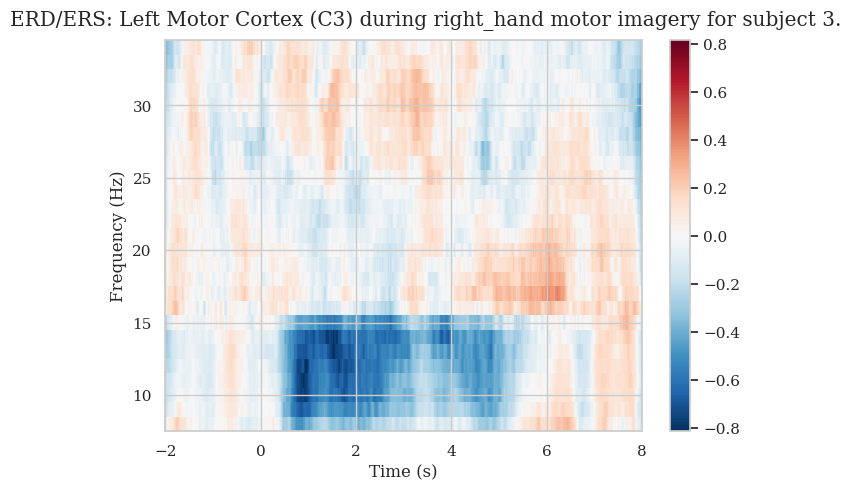

2026-02-28 22:09:11,123 WARNING MainThread moabb.paradigms.motor_imagery Choosing from all possible events


Loading data for Subject 9...
Filtered for left_hand
Calculating TFR...


<Figure size 1000x400 with 0 Axes>

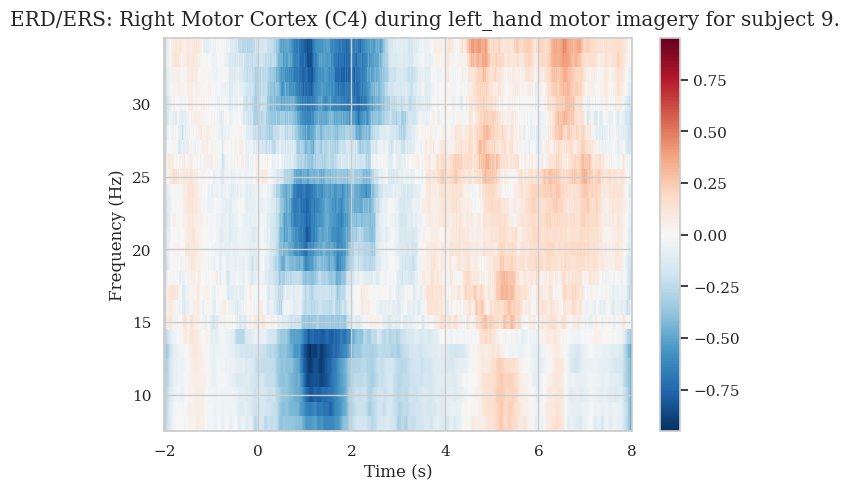

2026-02-28 22:09:18,582 WARNING MainThread moabb.paradigms.motor_imagery Choosing from all possible events


Bad performing subject:
Loading data for Subject 2...
Filtered for left_hand
Calculating TFR...


<Figure size 1000x400 with 0 Axes>

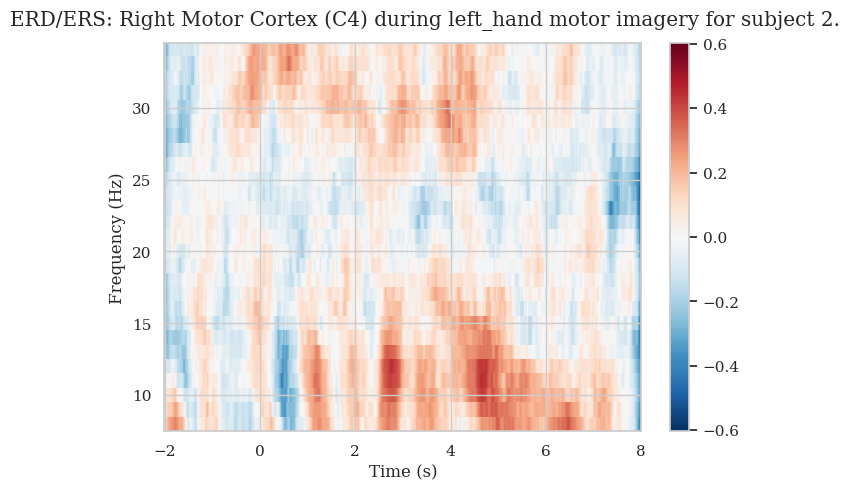

2026-02-28 22:09:26,720 WARNING MainThread moabb.paradigms.motor_imagery Choosing from all possible events







 Honorable Mentions:
Loading data for Subject 3...
Filtered for left_hand
Calculating TFR...


<Figure size 1000x400 with 0 Axes>

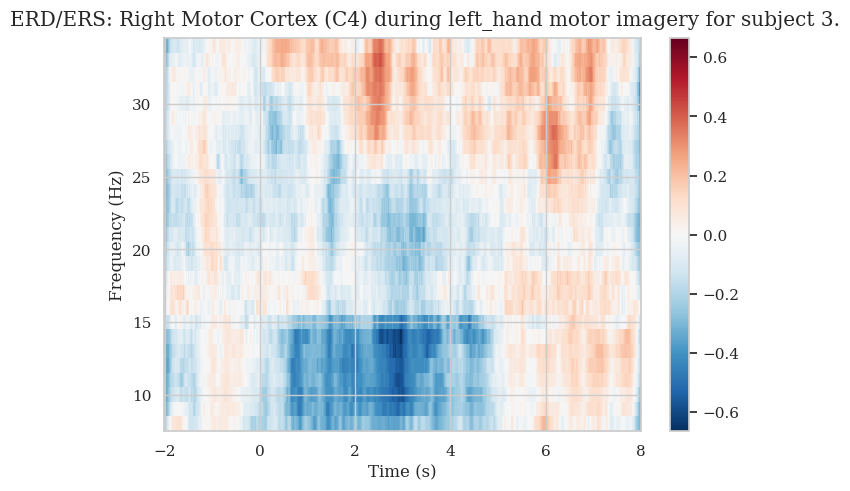

2026-02-28 22:09:34,316 WARNING MainThread moabb.paradigms.motor_imagery Choosing from all possible events


Loading data for Subject 8...
Filtered for left_hand
Calculating TFR...


<Figure size 1000x400 with 0 Axes>

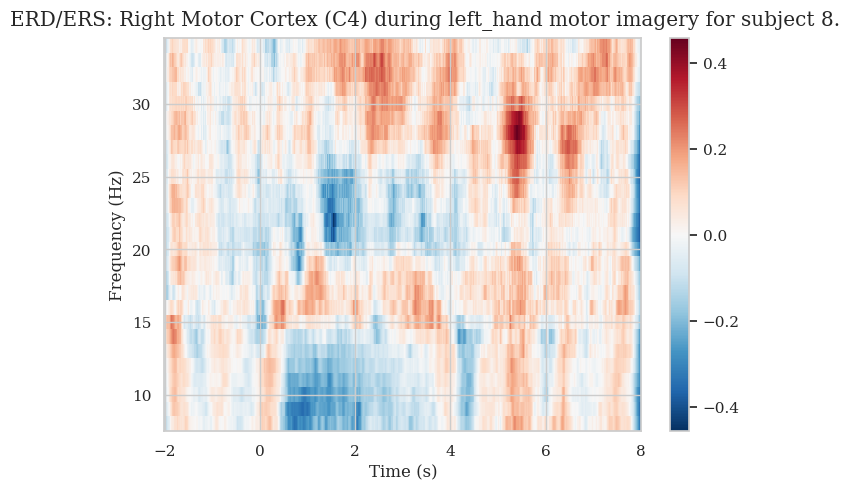

2026-02-28 22:09:41,933 WARNING MainThread moabb.paradigms.motor_imagery Choosing from all possible events


Loading data for Subject 5...
Filtered for right_hand
Calculating TFR...


<Figure size 1000x400 with 0 Axes>

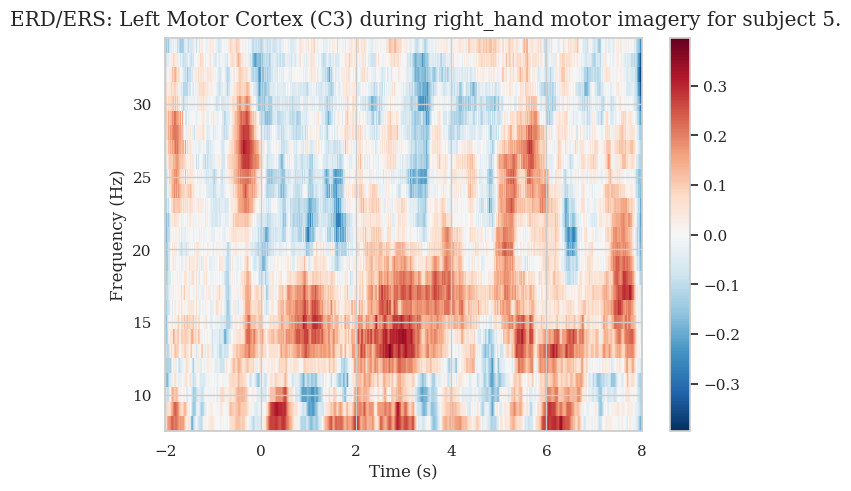

In [ ]:
def plot_tfr_vis(subj, target_class, ch_name):

    '''
    Plots the Time-Frequency Visualization during Motor Imagery for a given Subject, Class and Electrode Channel.

    Args: 
        subj (int): Between 1-9
        target_class (str): Indicates target class for plotting (either left_hand, right_hand, feet, tongue)
        ch_name (str): Important: Closely related to target class if the intention is to see the motor imagery for the contralateral brain region.
            If target_class = left_hand -> ch_name = C4 
            If target_class = right_hand -> ch_name = C3
            If target_class = feet -> ch_name = Cz
            If target_class = tongue -> ch_name = FCz/Cz (tongue is much more hard to "find")
    
    Interpretation:
    <0 seconds:   Before Motor Imagery (Participant is looking at a cross)
    0-4 seconds:  Onset/Duration of Motor Imagery (Participant imagines moving one of the target classes)
    >4 seconds:   Official ending for Motor Imagery task (Participant is, again, looking at a cross waiting for the next class)
    '''

    # Data loading
    subject = subj # Try out 3, 8 or 9 (good subjects) or 2 (bad)
    print(f"Loading data for Subject {subject}...")

    dataset = BNCI2014_001()
    # paradigm = LeftrightImagery(fmin=1, fmax=45)
    paradigm = MotorImagery(fmin = 1, fmax= 45)
    X, y, metadata = paradigm.get_data(dataset=dataset, subjects=[subject])

    # Extracting MNE epochs from MOABB. bit convoluted...
    raw_dict = dataset.get_data(subjects=[subject])
    session = list(raw_dict[subject].keys())[0]
    run = list(raw_dict[subject][session].keys())[0]
    raw = raw_dict[subject][session][run]

    # Broad initial filter
    raw.filter(1, 45)

    # Create events and epochs manually for MNE plotting
    events, event_ids = mne.events_from_annotations(raw) # 4 events: left_hand, right_hand, feet, tongue

    # Filter for Right Hand (to see ERD in C3)
    target_class = target_class
    if target_class in event_ids:
        events = events[events[:, 2] == event_ids[target_class]]
        print(f"Filtered for {target_class}")
    else: 
        print(f"{target_class} is not a correct target. Try 'left_hand', 'right_hand', 'feet' or 'tongue'")
        return None

    tmin, tmax = -2, 8  # Start earlier to capture baseline, and end later to see the rebound
    epochs = mne.Epochs(raw, events, tmin= tmin, tmax= tmax, baseline=None)

    # Calculate Time-Frequency Representation (TFR)
    # Look at C3 (Left Motor) and C4 (Right Motor)
    freqs = np.arange(8, 35, 1) # 8 to 35 Hz
    n_cycles = freqs / 2.0  # Different number of cycles per frequency

    print("Calculating TFR...")
    power = tfr_multitaper(epochs, freqs=freqs, n_cycles=n_cycles, time_bandwidth = 4.0, use_fft=True,    # Creates the TFR and averages accross the trials.
                       return_itc=False, average=True)             
    # Plot
    # C3 = Left Hemisphere WHEN Right hand | C4 = Right Hemisphere WHEN Left Hand
    # If they move RIGHT hand, C3 should turn BLUE (ERD).

    ch_name = ch_name
    pick = [raw.ch_names.index(ch_name)] if ch_name in raw.ch_names else [0]
    cortex_loc = "Right Motor Cortex" if ch_name in ['C4','C6','CP4','CP6'] else "Left Motor Cortex" if ch_name in ['C3','C5','CP3','CP5'] else 'Midline Central' if ch_name in ['Cz'] else 'Unknown'

    plt.figure(figsize = (10, 4))
    power.plot(pick, baseline=(-1.5, -0.5) , mode='logratio', title=f'ERD/ERS: {cortex_loc} ({ch_name}) during {target_class} motor imagery for subject {subj}.')
    plt.show() 
    return power

# Examples:

# plot_tfr_vis(SUBJECT_NUMBER, MOTOR IMAGERY TASK, CHANNEL NUMBER)
s3_righthand_c3 = plot_tfr_vis(subj = 3, target_class = 'right_hand', ch_name = 'C3')

# Tip: If you want to, play around with it after you see the subject specific performances later. As a sneak peek:
s9_lefthand_c4 = plot_tfr_vis(9 ,'left_hand', 'C4')  # Top Performer
print('Bad performing subject:')
s2_lefthand_c4 = plot_tfr_vis(2, 'left_hand', 'C4')  # Bad Performer

    # See: How clear is their ERD? Is there a clear desync at motor imagery onset? 
    # Maybe this explains their accuracy accross the board (see more on this later)

# Honorable Mentions:
print(f'='*125,'\n'*6,"Honorable Mentions:")
s3_lefthand_c4 = plot_tfr_vis(3, 'left_hand', 'C4')
s8_lefthand_c4 = plot_tfr_vis(8,'left_hand', 'C4' )
s5_righthand_c3 = plot_tfr_vis(5, 'right_hand', 'C3') # pretty bad!


# Experiment!

> **Note:** As observed, not every subject has the clear *theoretical* brain response to the task. This reflects the inherent challenge of EEG analysis, where signal-to-noise ratios, anatomical differences, and cognitive engagement vary significantly between individuals. This absence is consistent with BCI literature; Pfurtscheller et al. (2005) reported that the beta rebound (ERS) is highly subject- and task-specific and does not manifest in all individuals during motor imagery.

# **Spatial Location of ERD and ERS**
The previous time-frequency plot shows *when* specific rhythms change. For spatial information, we have to look at topographical maps. The `mne-python` library provides tools to visualize the spatial distribution of brain activity. This validates that our signals originate from the biological motor cortex rather than artifact noise (like eye blinks).

## *Target Biological Signatures:*
- **Baseline**: Before 0 seconds, participant is looking at red cross. This is the baseline set for the time-frequency plotting.
- **Active Phase (ERD):** During the imagery task (0.5–2.5s), we filter for the **Mu band (8–13 Hz)**. We expect a localized power decrease (**blue region**) over the contralateral motor cortex.
- **Recovery Phase (ERS):** After the imagery concludes (>2.5s), we filter for the **Beta band (15–30 Hz)**. We expect a power increase (**red region**) or return to baseline (**white region**) as the motor neurons re-synchronize to a resting state

> **Note:** The TFR visualization is currently coupled with the spatial mapping. Therefore, the time-frequency function has to be first stored in a variable (see previous code block). Then run the code block below.
>
> Overall, this is already initialized, but if you want to experiment with other participants/electrodes/classes, run those specifics on the TFR function first and specifiy the variable to use with `plot_erd_topomap`. 

Subject 3, Left Hand, C4


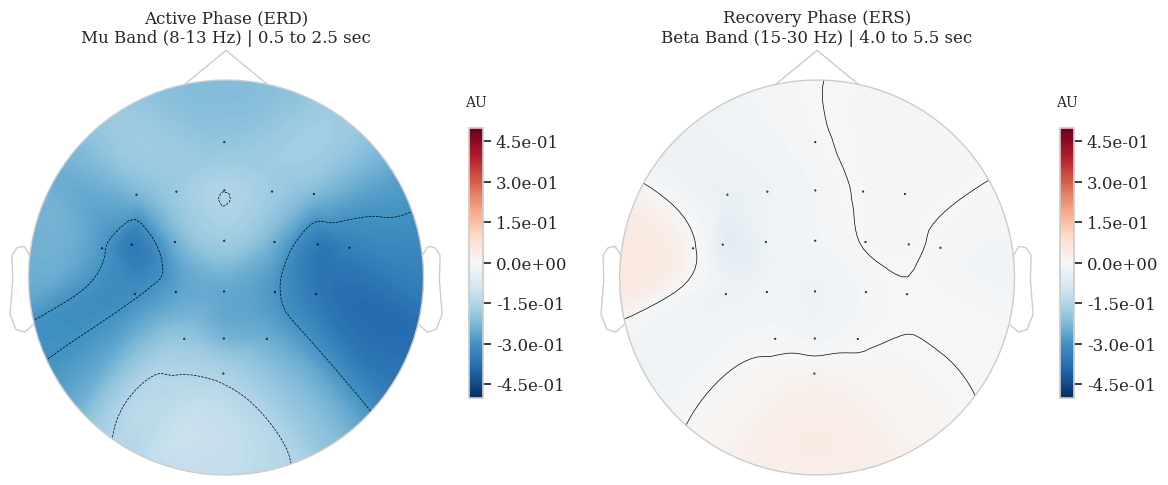

Subject 3, Right Hand, C3


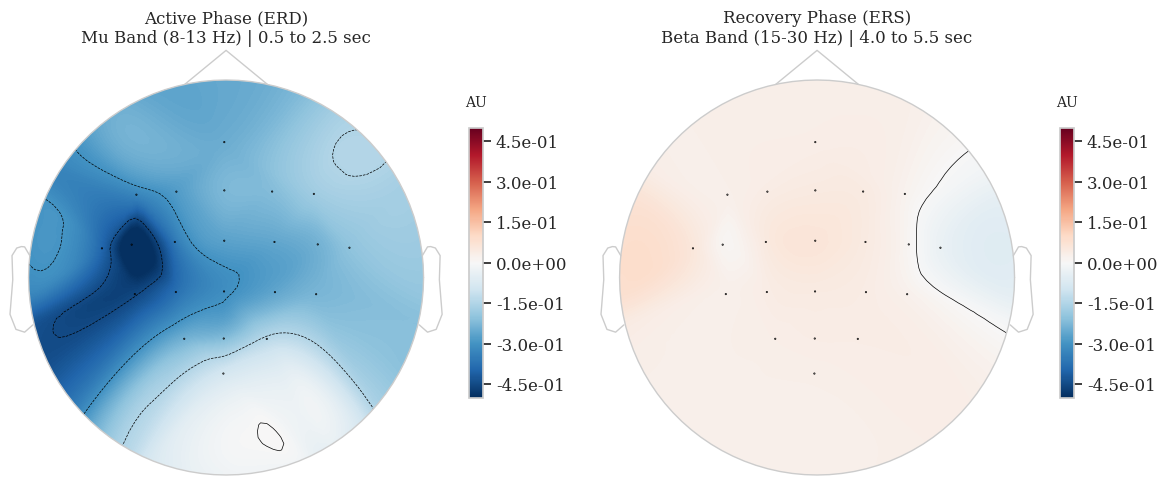

Subject 2, Left Hand, C4


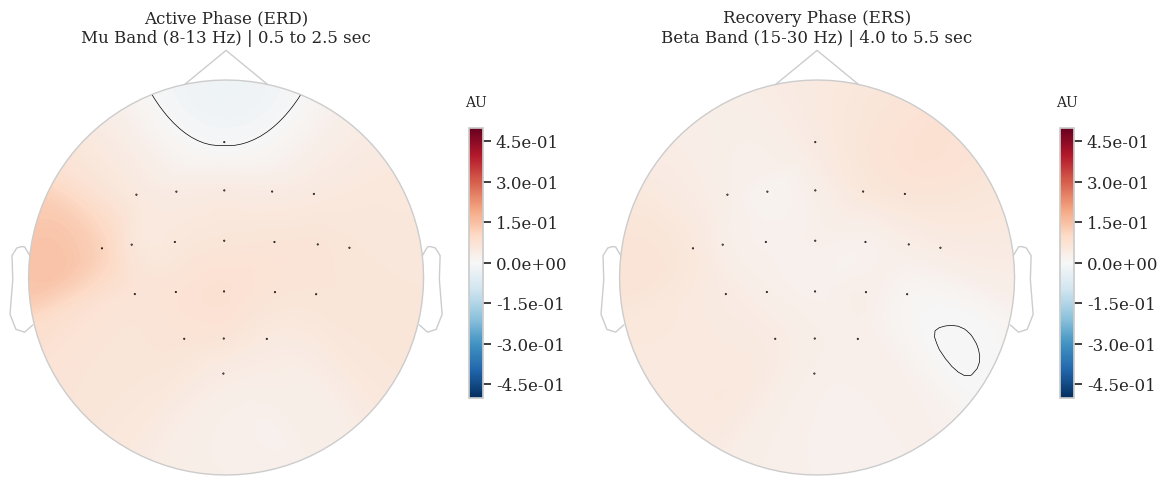

Subject 8, Left Hand, C4


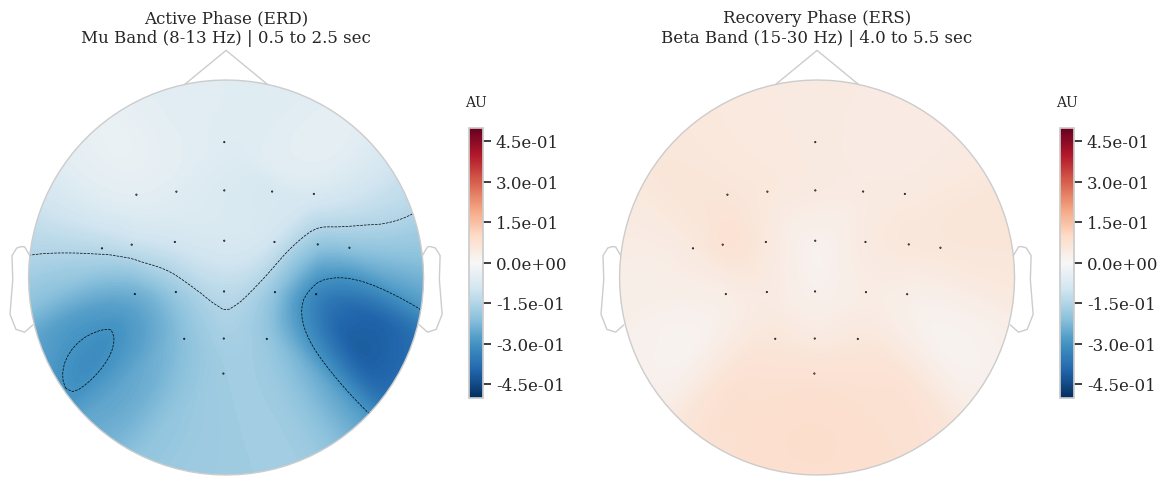

In [4]:
def plot_erd_topomap(tfr_data, baseline=(-1.5, -0.5), vlim=(-0.5, 0.5)):
    """
    Plots the Active (ERD) and Recovery (ERS) phases side-by-side.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # 1. Active Phase: Mu Band ERD (Power Drop)
    tfr_data.plot_topomap(
        tmin=0.5, tmax=2.5, fmin=8, fmax=13,
        baseline=baseline, 
        mode='logratio',    # Either use "percentage" or "logratio". 
                            # "Percentage" is easier to interpret and provides clear results (e.g., -40% means -40% loss of idling rhythm.). However, its asymmetrical, and sensitive to low-power baselines,
                            # Meanwhile, "logratio" converts power change to a logarithmic scale. Handles baseline amplitudes gracefully. It does complicate interpretation though due to logarithmic scale. I got clearer visualizations using it.                            
        
        cmap='RdBu_r',       # Blue = ERD (-), Red = ERS (+)
        vlim=vlim,           
        axes=axes[0],
        colorbar=True,
        show=False
    )
    axes[0].set_title('Active Phase (ERD)\nMu Band (8-13 Hz) | 0.5 to 2.5 sec')

    # 2. Recovery Phase: Beta Rebound ERS (Power Increase)
    tfr_data.plot_topomap(
        tmin=4.0 , tmax=5.5, fmin=16, fmax=30,             
        baseline=baseline, 
        mode='logratio', 
        cmap='RdBu_r', 
        vlim=vlim,
        axes=axes[1],
        colorbar=True,
        show=False
    )
    axes[1].set_title('Recovery Phase (ERS)\nBeta Band (15-30 Hz) | 4.0 to 5.5 sec')

    plt.tight_layout()
    plt.show()

# --- Examples ---

# Plot the ERD during the active movement phase and after movement phase
# plot_erd_topomap(s3_lefthand_c4)
print('Subject 3, Left Hand, C4')
plot_erd_topomap(s3_lefthand_c4)
print('Subject 3, Right Hand, C3')
plot_erd_topomap(s3_righthand_c3) # Best rep
print('Subject 2, Left Hand, C4')
plot_erd_topomap(s2_lefthand_c4)
print('Subject 8, Left Hand, C4')
plot_erd_topomap(s8_lefthand_c4)


### Biological Interpretation of Spatial Topography

The topomaps provide a clearer picture for the spatial organization of the ERD signals. Consistent with neurophysiological expectations for **Right Hand** imagery:

*   **Active Phase (Left):** In some subjects it displays a distinct, localized power drop (**ERD**) over the **Left Motor Cortex (C3)**. This confirms the contralateral desynchronization required for motor simulation. Alongside, the *Left Hand* imagery displays a **Right Motor Cortex (C4)** ERD. However, this is not consistent.
*   **Recovery Phase (Right):** Marks the cessation of imagery. While a strong Beta Rebound (ERS) typically appears red, this region often remains white. Literature indicates that ERS is significantly less pronounced in Motor Imagery than in Motor Execution, largely due to the lack of somatosensory feedback (Chen et al., 2005). This absence likely stems from physiological variability and signal-to-noise constraints, rather than an error in the processing pipeline. The *white* in the recovery phase could also be interpreted as the brain returning to **baseline levels**. It shows the participant going back to the "resting state" after the movement prompt.

### The Challenge of "BCI Illiteracy"
Contrast the clear patterns of **Subject 3** with **Subject 2**. The visualization reveals **no observable ERD** or lateralization for the latter. This demonstrates the phenomenon of **BCI Illiteracy** (Vidaurre & Blankertz, 2010) and poses a fundamental challenge: *How can a model accurately predict the class when the underlying physiological signal is effectively absent?* 

This is what we will tackle next.

---

> **A Note on Preprocessing and Artifacts:**
> In this project, I chose not to use **ICA (Independent Component Analysis)** for artifact rejection. While ICA is standard in clinical EEG to remove eye blinks and muscle noise, modern Deep Learning, and Brain-Computer-Interfaces specifically often prefer minimally processed data.
> 
> Additionally, most visualization in this code uses a **frequency filter**, that is between ~**8-45**. This means that we ignore frequencies below 8, which effectively reduces eye blink artifacts immediately. This is further confirmed by our **Saliency Maps** and **Topomaps**. We can see that the brain activity and model importance is located in the **Central (C3/C4)** regions of the scalp. If eye blinks, or other artifacts would've dictated decision-making, we would see those electrodes have more importance for the model. Of course, rejecting artifacts may give benefits to the model as it removes unnecessary noise, but this implementation focuses on a more **end-to-end** system.

# Deep Learning Model Initialization

The following code defines the custom PyTorch neural networks used for motor imagery decoding, as well as the unified wrapper class required to integrate these PyTorch models into the `scikit-learn` and MOABB evaluation pipelines.

### 1. The Neural Network Architectures
Two distinct Convolutional Neural Networks (CNNs) are implemented to process the 3D EEG tensors `(trials, channels, time)`:

*   **SimpleCNN:** A custom architecture designed to mimic classical BCI processing. It applies a temporal convolution (acting as a learnable bandpass filter) followed by a spatial convolution (combining electrode signals), before passing the features through a deep extraction block and a final classification layer.
*   **EEGNetv4 (Lawhern et al., 2018):** A very famous, compact CNN for EEG. It utilizes depthwise and separable convolutions to aggressively reduce the number of trainable parameters, mitigating the risk of overfitting on small EEG datasets.

### 2. The `CNNEstimator` (Scikit-Learn Wrapper)
MOABB's evaluation framework relies strictly on the standard `scikit-learn` API (`fit`, `predict`, `transform`). Because raw PyTorch models cannot be directly passed into MOABB pipelines, the `CNNEstimator` bridges this gap while handling critical EEG-specific training dynamics:

*   **API Compatibility:** Inherits from `BaseEstimator`, `ClassifierMixin`, and `TransformerMixin`. This makes the PyTorch code "look and act" exactly like a standard machine learning object.
*   **Channel-Wise Standardization:** The estimator automatically applies `StandardScaler` channel-wise, for better learning outcomes.
*   **Regularization & MaxNorm Constraints:** To prevent the model from memorizing session-specific biological artifacts (like eye blinks or muscle noise), the estimator applies Weight Decay. For EEGNet, it enforces **MaxNorm constraints** on the spatial and fully-connected layers, as done in the original paper.
*   **Learning Rate Scheduling:** Implements `ReduceLROnPlateau` to dynamically lower the learning rate as the model approaches the optimal loss, stabilizing the training process.

### 3. End-to-End vs. Hybrid Modeling
By integrating both `.predict()` and `.transform()` methods, the `CNNEstimator` serves a dual purpose depending on how the pipeline is constructed:
*   **As a Classifier (`.predict()`):** If used standalone, it passes the data through the entire network and outputs the final class prediction.
*   **As a Feature Extractor (`.transform()`):** When placed early in a pipeline (e.g., `make_pipeline(CNNEstimator(...), LDA())`), Scikit-Learn automatically calls `.transform()`. This stops the network just before the final Linear layer, outputting the penultimate layer's abstract features. This allows the CNN to act purely as a feature extractor, feeding optimized representations into a classical classifier like Linear Discriminant Analysis (LDA) to create a **Hybrid model**.

In [5]:
class SimpleCNN(nn.Module):
    def __init__(self, n_channels, n_classes, n_times):
        super(SimpleCNN, self).__init__()
        
        
        # BLOCK 1: Basic Feature Extraction
        
        # 1. Temporal Convolution
        # Input: (Batch, 1, Channels, Time)
        # Kernel: (1, 25) -> Slides across TIME only.
            # Meaning: This acts like a bandpass filter. It learns to extract specific frequencies (like Mu/Beta rhythms) from each electrode independently.

        self.conv_time = nn.Conv2d(1, 16, kernel_size=(1, 25), stride=1, padding=(0, 12))
        self.bn1 = nn.BatchNorm2d(16) # Normalizes data to speed up training
        
        
        # 2. Spatial Convolution
        # Input: (Batch, 16, Channels, Time)
        # Kernel: (Channels, 1) -> Slides across CHANNELS only.
            # Meaning:  It assings high weights for electrodes that are important for classification, and limits those that are not. Similar to a CSP. 

        self.conv_spat = nn.Conv2d(16, 32, kernel_size=(n_channels, 1), stride=1, bias=False)
        self.bn2 = nn.BatchNorm2d(32)
        
        # 3. Pooling
            # Meaning: Reduces the resolution, gives a "general trend" of brain activity instead of every milisecond.
        self.pool = nn.AvgPool2d(kernel_size=(1, 75), stride=(1, 15))
        self.dropout = nn.Dropout(0.5) # Randomly zeros out neurons to prevent overfitting. (Very Important!)
        
    
        # BLOCK 2: Deep Feature Extraction (later addition)

        # Why added? The 4-class problem (Hands + Feet + Tongue) is harder. 
        # A single layer isn't enough to separate overlapping patterns.
        # This block allows the network to learn "patterns of patterns".
        
        # 4. Second Temporal Convolution
        # Input: (Batch, 32, 1, Reduced_Time)
        # Meaning: Looks for sequences of the spatial patterns found above.
        self.conv_time2 = nn.Conv2d(32, 64, kernel_size=(1, 15), stride=1, padding=(0, 7))
        self.bn3 = nn.BatchNorm2d(64)
        self.pool2 = nn.AvgPool2d(kernel_size=(1, 10), stride=(1, 5))
        self.dropout2 = nn.Dropout(0.5)
        
        # CLASSIFICATION HEAD
        
        # 5. Global Pooling
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        # 6. Fully Connected Layer
        # Meaning: Takes the 64 abstract features and votes for the 4 classes.
        self.fc = nn.Linear(64, n_classes)

    def forward(self, x):
        # x: (Batch, 1, Channels, Time)
        
        # --- Block 1 ---
        x = self.conv_time(x)
        x = self.bn1(x)
        x = torch.relu(x) # Standard ReLu activation function
        
        x = self.conv_spat(x)
        x = self.bn2(x)
        x = torch.relu(x)
        
        x = self.pool(x)
        x = self.dropout(x)
        
        # --- Block 2 ---
        x = self.conv_time2(x)
        x = self.bn3(x)
        x = torch.relu(x)
        x = self.pool2(x)
        x = self.dropout2(x)
        
        # --- Classification ---
        x = self.global_pool(x)
        x = x.view(x.size(0), -1) # Flatten
        x = self.fc(x)
        return x

    def extract_features(self, x):
        """Returns the penultimate layer features"""
        # x: (Batch, 1, Channels, Time)
        
        # --- Block 1 ---
        x = self.conv_time(x)
        x = self.bn1(x)
        x = torch.relu(x)
        
        x = self.conv_spat(x)
        x = self.bn2(x)
        x = torch.relu(x)
        
        x = self.pool(x)
        x = self.dropout(x)
        
        # --- Block 2---
        x = self.conv_time2(x)
        x = self.bn3(x)
        x = torch.relu(x)
        x = self.pool2(x)
        x = self.dropout2(x)
        
        # --- Classification ---
        x = self.global_pool(x)
        x = x.view(x.size(0), -1) # Flatten
        # No final dense layer. Returns the penultimate layer as an input for Hybrid model.
        return x

class EEGNetv4(nn.Module):
    """
    Famous compact CNN for EEG (Lawhern et al., 2018).
    Uses Depthwise and Separable Convolutions to reduce parameters while retaining performance.
    Important Disclosure: The last layer is modified to Global Average Pooling as it fits better for our specific use-case and reduces overfitting. 
    """
    def __init__(self, n_channels, n_classes, n_times, dropoutRate=0.5, kernLength=64, F1=8, D=2, F2=16):
        super(EEGNetv4, self).__init__()
        self.F1 = F1
        self.F2 = F2
        self.D = D
        
        # Block 1: Temporal Conv -> Depthwise Spatial Conv
        self.conv1 = nn.Conv2d(1, F1, (1, kernLength), padding=(0, kernLength // 2), bias=False)
        self.bn1 = nn.BatchNorm2d(F1)
        
        # Depthwise: Learns spatial filters for each temporal filter separately
        self.conv2 = nn.Conv2d(F1, F1 * D, (n_channels, 1), groups=F1, bias=False)
        self.bn2 = nn.BatchNorm2d(F1 * D)
        self.elu = nn.ELU()
        self.avgpool1 = nn.AvgPool2d((1, 4))
        self.dropout1 = nn.Dropout(dropoutRate)
        
        # Block 2: Separable Conv (Pointwise -> Depthwise)
        self.conv3 = nn.Conv2d(F1 * D, F1 * D, (1, 16), padding=(0, 8), groups=F1 * D, bias=False)
        self.conv4 = nn.Conv2d(F1 * D, F2, (1, 1), bias=False)
        self.bn3 = nn.BatchNorm2d(F2)
        self.avgpool2 = nn.AvgPool2d((1, 8))
        self.dropout2 = nn.Dropout(dropoutRate)
        
        self.flatten = nn.Flatten()
        
        # Calculate output size dynamically
        # For 1000 time points (approx): 1000 -> /4 -> 250 -> /8 -> 31

        
        # final_time_dim = n_times // 32 
        # self.fc = nn.Linear(F2 * final_time_dim, n_classes)
        
        # New Robust Classifier: Global Average Pooling
        # This makes the model input-size invariant (works for any duration)
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)), # Avg across all remaining time points -> (Batch, F2, 1, 1)
            nn.Flatten(),                 # -> (Batch, F2)
            nn.Linear(F2, n_classes)      # F2 is fixed (16), so this never breaks
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.elu(x)
        x = self.avgpool1(x)
        x = self.dropout1(x)
        
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.bn3(x)
        x = self.elu(x)
        x = self.avgpool2(x)
        x = self.dropout2(x)
        
        x = self.classifier(x)
        return x
    def extract_features(self, x):
        """Returns the penultimate layer features"""
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.elu(x)
        x = self.avgpool1(x)
        x = self.dropout1(x)
        
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.bn3(x)
        x = self.elu(x)
        x = self.avgpool2(x)
        x = self.dropout2(x)
        
        # Apply the Pooling and Flatten parts of the classifier, but NOT the Linear layer
        x = self.classifier[0](x) # AdaptiveAvgPool
        x = self.classifier[1](x) # Flatten
        return x


# Scikit-learn wrapper class

class CNNEstimator(ClassifierMixin, BaseEstimator, TransformerMixin):
    _estimator_type = "classifier"
    def __init__(self, n_epochs=10, batch_size=32, learning_rate=0.001, model_type="SimpleCNN", pretrained_weights=None, early_stopping=False, patience=10, weight_decay=0.0001, val_split=0.15):
        self.n_epochs = n_epochs
        self.batch_size = batch_size
        self.learning_rate = learning_rate
        self.model_type = model_type
        self.pretrained_weights = pretrained_weights
        self.early_stopping = early_stopping
        self.patience = patience
        self.weight_decay = weight_decay
        self.val_split = val_split
        self.model = None
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.scaler = None
        self.le = None
        self.classes_ = None

    def fit(self, X, y):
        # MOABB X is (n_epochs, n_channels, n_times)
        # We need (n_epochs, 1, n_channels, n_times)
        '''
        An older implementation for scaling the inputs, as very small numbers are often problematic for deep learning.
        # --- 1. Automatic Scaling ---
        if np.std(X) < 1e-4:
            print(f"  > [Auto-Scale] Input data seems to be in Volts. Scaling by 1e6 to uV for stability.")
            self.scaling_factor = 1e6
            X = X * self.scaling_factor
        else:
            self.scaling_factor = 1.0
        # -----------------------------------------------------------------
        '''
        # Instead, apply Channel-wise scaling for robust training (Repeated at predict function)
        nt, nc, ns = X.shape
        X_flat = X.transpose(0, 2, 1).reshape(-1, nc)
        self.scaler = StandardScaler()
        X_flat = self.scaler.fit_transform(X_flat)
        X = X_flat.reshape(nt, ns, nc).transpose(0, 2, 1)


        # Handle string labels
        self.le = LabelEncoder()
        y_encoded = self.le.fit_transform(y)
        self.classes_ = self.le.classes_
        
        # Data Splitting for Early Stopping
        if self.early_stopping:
            # Split val_split (default 15%) to keep more data for training while still validating
            X_train, X_val, y_train, y_val = train_test_split(X, y_encoded, test_size=self.val_split, random_state=42, stratify=y_encoded)
            
            X_tensor = torch.FloatTensor(X_train).unsqueeze(1).to(self.device) # adds a 'singleton' dimension at index 1 for shape compatibility.
            y_tensor = torch.LongTensor(y_train).to(self.device)
            
            # Validation tensors (keep on device)
            X_val_tensor = torch.FloatTensor(X_val).unsqueeze(1).to(self.device)
            y_val_tensor = torch.LongTensor(y_val).to(self.device)
        else:
            # Use all data
            X_tensor = torch.FloatTensor(X).unsqueeze(1).to(self.device)
            y_tensor = torch.LongTensor(y_encoded).to(self.device)
            X_val_tensor, y_val_tensor = None, None

        dataset = TensorDataset(X_tensor, y_tensor)
        dataloader = DataLoader(dataset, batch_size=self.batch_size, shuffle=True)
        
        n_channels = X.shape[1]
        n_times = X.shape[2]
        n_classes = len(self.le.classes_)
        
        if self.model_type == "EEGNetv4": # Model choice logic
            self.model = EEGNetv4(n_channels=n_channels, n_classes=n_classes, n_times=n_times).to(self.device)
        else:
            self.model = SimpleCNN(n_channels=n_channels, n_classes=n_classes, n_times=n_times).to(self.device)
            
        if self.pretrained_weights is not None:
            print(f"Loading pre-trained weights into {self.model_type}...")
            self.model.load_state_dict(self.pretrained_weights)
        else:
            # Explicit Weight Initialization (Kaiming He) for stability
            def init_weights(m):
                if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                    nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            self.model.apply(init_weights)

        criterion = nn.CrossEntropyLoss()
        # Added Weight Decay (L2 Regularization) to prevent overfitting
        optimizer = optim.Adam(self.model.parameters(), lr=self.learning_rate, weight_decay=self.weight_decay)
        # Added Scheduler: Reduce LR if validation loss stops improving
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5) # factor 0.2 or 0.5
        
        self.train_losses = [] # Store loss history for plotting
        
        best_loss = float('inf')
        patience_counter = 0
        best_weights = None
        weight_number = 1
        
        self.model.train()
        for epoch in range(self.n_epochs):
            running_loss = 0.0
            correct = 0
            total = 0
            for batch_X, batch_y in dataloader:
                optimizer.zero_grad()
                outputs = self.model(batch_X)
                loss = criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()
            # ---------------------------EEGNetv4 MaxNorm Constraint----------------------------

                if self.model_type == "EEGNetv4":
                    # 1. Constrain Spatial Filters (conv2)
                    # Weight shape is [Filters, 1, Channels, 1]
                    spatial_weights = self.model.conv2.weight
                    for i in range(spatial_weights.shape[0]): # Loop through each filter
                        norm = spatial_weights[i].data.norm(2)
                        if norm > 1.0:
                            spatial_weights[i].data.mul_(1.0 / norm)

                    # 2. Constrain Classifier
                    # Weight shape is [Classes, Features]
                    fc_weights = self.model.classifier[2].weight
                    for i in range(fc_weights.shape[0]): # Loop through each class's weights
                        norm = fc_weights[i].data.norm(2)
                        if norm > 0.25:
                            fc_weights[i].data.mul_(0.25 / norm)
                
            # ----------------------------------------------------------------------------------

                running_loss += loss.item()
                
                _, predicted = torch.max(outputs.data, 1)
                total += batch_y.size(0)
                correct += (predicted == batch_y).sum().item()
            
            avg_loss = running_loss / len(dataloader)
            accuracy = 100 * correct / total
            self.train_losses.append(avg_loss) # Average loss per batch
            
            # Early Stopping Check
            if self.early_stopping and X_val_tensor is not None:
                self.model.eval()
                with torch.no_grad():
                    val_out = self.model(X_val_tensor)
                    val_loss = criterion(val_out, y_val_tensor).item()
                self.model.train()
                
                # Step the scheduler
                scheduler.step(val_loss)
                
                if val_loss < best_loss:
                    best_loss = val_loss
                    patience_counter = 0
                    best_weights = copy.deepcopy(self.model.state_dict())
                    weight_number = epoch + 1
                else:
                    patience_counter += 1
                    
                if patience_counter >= self.patience:
                    print(f"Early stopping at epoch {epoch+1} (Best Val Loss: {best_loss:.4f} at {weight_number}th epoch)")
                    self.model.load_state_dict(best_weights)
                    break

            # Monitor GPU usage every 10 epochs :)
            if (epoch + 1) % 10 == 0:
                if self.device.type == 'cuda':
                    mem_alloc = torch.cuda.memory_allocated(self.device) / 1024**2 # MB
                    mem_res = torch.cuda.memory_reserved(self.device) / 1024**2  # MB
                    print(f"{self.model_type} | Epoch {epoch+1}/{self.n_epochs} | Loss: {avg_loss:.4f} | Acc: {accuracy:.2f}% | GPU Mem: {mem_alloc:.1f}MB / {mem_res:.1f}MB")
                else:
                    print(f"{self.model_type} | Epoch {epoch+1}/{self.n_epochs} | Loss: {avg_loss:.4f} | Acc: {accuracy:.2f}%")

        # Restore best weights if we stopped early
        if self.early_stopping and best_weights is not None:
            self.model.load_state_dict(best_weights)
            
        return self

    def predict(self, X):
        'Gives class predictions for a given dataset'
        nt, nc, ns = X.shape                                    # A bit ugly but has to be done for StandardScaler to work.
        X_flat = X.transpose(0, 2, 1).reshape(-1, nc)           # Transforms (Trials, Channels, Time) to (Samples, Features).
        X_flat = self.scaler.transform(X_flat) # USE TRANSFORM, NOT FIT!
        X = X_flat.reshape(nt, ns, nc).transpose(0, 2, 1)
    
        # Proceeding with model.eval() and torch.no_grad()
        self.model.eval()
        X_tensor = torch.FloatTensor(X).unsqueeze(1).to(self.device)
        with torch.no_grad():
            outputs = self.model(X_tensor)
            _, predicted = torch.max(outputs.data, 1)
        return self.le.inverse_transform(predicted.cpu().numpy())


    def predict_proba(self, X):
        """Returns class probabilities."""
        nt, nc, ns = X.shape                                
        X_flat = X.transpose(0, 2, 1).reshape(-1, nc)
        X_flat = self.scaler.transform(X_flat)
        X = X_flat.reshape(nt, ns, nc).transpose(0, 2, 1)

        self.model.eval()
        X_tensor = torch.FloatTensor(X).unsqueeze(1).to(self.device)
        with torch.no_grad():
            outputs = self.model(X_tensor)
            probs = F.softmax(outputs, dim=1)
        return probs.cpu().numpy()
        
    def transform(self, X):
        """Transformer behavior: Returns penultimate layer features."""
        # Scale (Same as predict)
        nt, nc, ns = X.shape
        X_flat = X.transpose(0, 2, 1).reshape(-1, nc)
        X_flat = self.scaler.transform(X_flat)
        X = X_flat.reshape(nt, ns, nc).transpose(0, 2, 1)

        # Extract Features (NOT prediction)
        self.model.eval()
        X_tensor = torch.FloatTensor(X).unsqueeze(1).to(self.device)
        with torch.no_grad():
            # CALLS THE EXTRACTION METHOD IN THE PYTORCH MODEL
            features = self.model.extract_features(X_tensor)
        
        return features.cpu().numpy()


### **Model Parameter Counts**

In [ ]:
n_channels = 22   # Number of EEG electrodes
n_classes = 4    # Left Hand, Right Hand, Feet, Tongue
n_times = 1000    # Approx 4 seconds @ 250Hz (Standard epoch length)

print(f"Initializing models with: Channels={n_channels}, TimePoints={n_times}, Classes={n_classes}\n")

# 2. Initialize Models
simple_model = SimpleCNN(n_channels=n_channels, n_classes=n_classes, n_times=n_times)
eegnet_model = EEGNetv4(n_channels=n_channels, n_classes=n_classes, n_times=n_times)


totalparams = sum(p.numel() for p in simple_model.parameters())
learnableparams = sum(p.numel() for p in simple_model.parameters() if p.requires_grad)

totalparmsv4 = sum(p.numel() for p in eegnet_model.parameters())
learnableparamsv4 = sum(p.numel() for p in eegnet_model.parameters() if p.requires_grad)

print(f" Simple Model Total Parameters: {totalparams}")
print(f" Simple Model Learnable Parameters: {learnableparams}")

print(f" EEGNetv4 Total Parameters: {totalparmsv4}")
print(f" EEGNetv4 Learnable Parameters: {learnableparamsv4}")

Initializing models with: Channels=22, TimePoints=1000, Classes=4

 Simple Model Total Parameters: 42948
 Simple Model Learnable Parameters: 42948
 EEGNetv4 Total Parameters: 1524
 EEGNetv4 Learnable Parameters: 1524


# **Task 1: Binary Motor Imagery Classification**

## *Classes Evaluated:*
- **Left Hand:** Expected to produce Event-Related Desynchronization (ERD) over the right motor cortex (C4).
- **Right Hand:** Expected to produce ERD over the left motor cortex (C3).

## *Models & Pipelines:*
- **Classical Baselines:** CSP + LDA, LogVariance + Logistic Regression
- **Deep Learning:** SimpleCNN, EEGNetv4 
- **Hybrid:** CNN Feature Extractor + LDA Classifier

## *Evaluation Strategy:*
- **Paradigm:** `LeftRightImagery` (Bandpass: 4–40 Hz).
- **Validation:** Cross-Session (Train on Day 1 $\rightarrow$ Test on Day 2).
- **Objective:** Test model robustness against EEG non-stationarity (cap shifts, impedance changes). 
- **Metric:** ROC-AUC / Accuracy (Chance level = **0.50**).

> ### **Warning**
> Running the full training loop is time-intensive and highly hardware-dependent (**~30-60 minutes** on a GTX 1650). 
> 
> **Note:** You can skip the training process by loading the pre-computed `left_right_results_confirmed.csv` included in the `data/` directory. The code block to load this file is located under this markdown.

In [7]:
df_2 = pd.read_csv('../data/left_right_results_confirmed.csv') # 2 class df

In [ ]:
# === Training Loop ===
# Optional to run

pipelines = {    

    "Hybrid (CNN+LDA)": make_pipeline(CNNEstimator(n_epochs=130, batch_size=32, learning_rate=0.001, early_stopping=False, patience=35, weight_decay=0.001, val_split = 0.15), LDA()),
    "EEGNet (Slow) 0.0005": CNNEstimator(n_epochs=140, batch_size=32, learning_rate=0.0005, early_stopping=False, patience=35, weight_decay=0.001, model_type="EEGNetv4", val_split= 0.15),
    "SimpleCNN 0.001": CNNEstimator(n_epochs=120, batch_size=16, learning_rate=0.01, early_stopping=False, patience=45, weight_decay=0.01, model_type="SimpleCNN", val_split= 0.15),
    "CSP + LDA": make_pipeline(CSP(n_components=8), LDA()),
    "LogVar + LDA": make_pipeline(LogVariance(),LDA()),                                                                     # Above are the best parameter settings I found for each model. 
                                                                                                                            # Perhaps utilizing the same hyperparameters instead would make it better for comparison,
     "LogVar + LogReg": make_pipeline(LogVariance(),LogisticRegression())                                                   # however I think showing all the models "in their best" is the most fair.
    }


dataset = BNCI2014_001()
dataset.subject_list = dataset.subject_list # use all subjects, index for specific subject (0 based)

print(f"Processing subjects: {dataset.subject_list}")

paradigm = LeftRightImagery(fmin=4, fmax=40)
evaluation = CrossSessionEvaluation(paradigm=paradigm, datasets=[dataset], overwrite=True) # classic MOABB paradigm 

results = evaluation.process(pipelines)
df_2= pd.DataFrame(results)
df_2.to_csv("../data/left_right_results.csv", index=False)
print(df_2.head())

# Visualization of results in NEXT CELL.

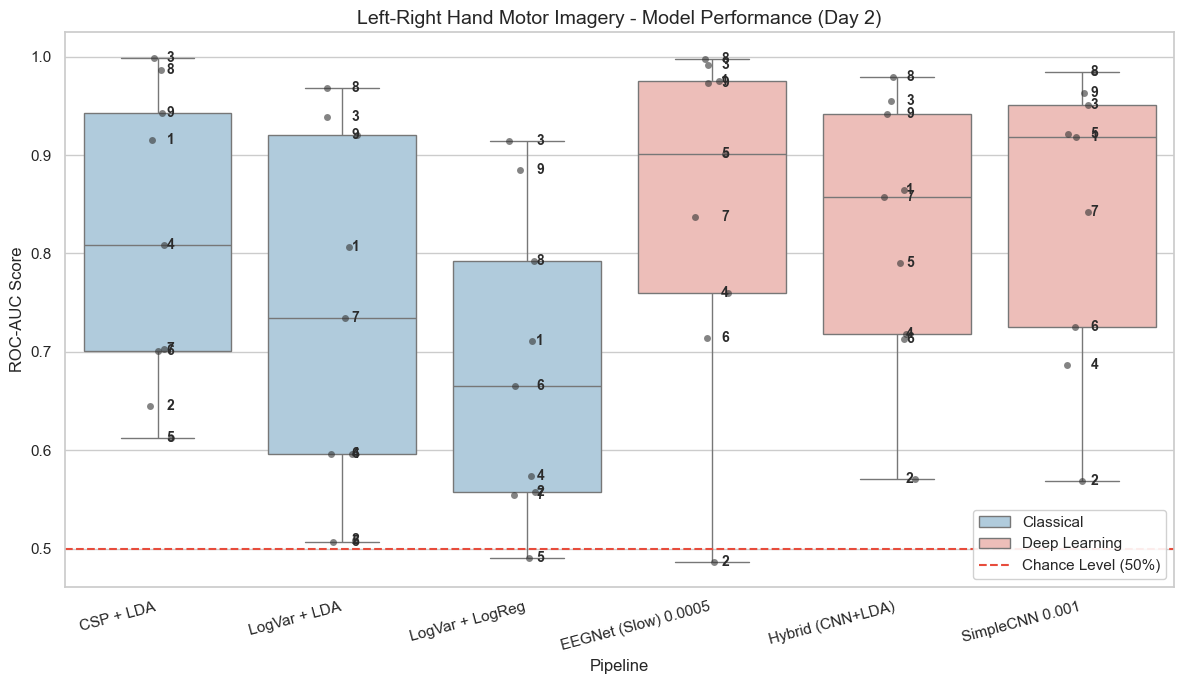

In [9]:
sns.set_theme(style="whitegrid")
# df_2 = pd.read_csv("../data/left_right_results_confirmed.csv")
plot_data2 = df_2[df_2["session"] == "1test"].copy()

# Category column for hue
# If name has CNN or EEGNet = Deep Learning. Otherwise, it's Classical.
plot_data2['Model Type'] = plot_data2['pipeline'].apply(
    lambda x: 'Deep Learning' if any(w in x for w in ['CNN', 'EEGNet']) else 'Classical'
)

# Classical First
plot_data2 = plot_data2.sort_values(by=['Model Type', 'pipeline'])

# Plotting
plt.figure(figsize=(12, 7))
my_colors = {"Classical": "#A9CCE3", "Deep Learning": "#F5B7B1"} # Soft Blue & Orange :)

# The boxes
ax = sns.boxplot(data=plot_data2, x="pipeline", y="score", hue="Model Type",
                 palette=my_colors, dodge=False, showfliers=False)

# Individuals
sns.stripplot(data=plot_data2, x="pipeline", y="score", 
              color="#333333", alpha=0.6, jitter=True)

# -----------------------------------Add Subject IDs to the dots--------------------------------
xtick_labels = [l.get_text() for l in ax.get_xticklabels()]
pipeline_map = {name: i for i, name in enumerate(xtick_labels)}

for i, row in plot_data2.iterrows():
    if row['pipeline'] in pipeline_map:
        x_pos = pipeline_map[row['pipeline']]

        ax.text(x_pos + 0.05, row['score'], str(row['subject']), 
                va='center', size='small', color='#2b2b2b', weight='semibold')
#----------------------------------------------------------------------------------------------------

# Formatting
plt.title("Left-Right Hand Motor Imagery - Model Performance (Day 2)", fontsize=14)
plt.ylabel("ROC-AUC Score", fontsize=12)
plt.xlabel("Pipeline", fontsize=12)

plt.axhline(0.5, color='#e74c3c', linestyle='--', label="Chance Level (50%)")
plt.xticks(rotation=15, ha='right')

handles, labels = ax.get_legend_handles_labels()
plt.legend(handles=handles, labels=labels, loc='lower right', framealpha=0.9)

plt.tight_layout()
# plt.savefig("leftright_clean.png", dpi=300)
plt.show()

> **Thoughts / Remarks:** Initially, it was very difficult to get the deep learning models to surpass CSP + LDA. I implemented a lot of standardization/ normalization features to tweak it the best possible way. 
> 
> During testing, I had a constant feeling of *randomness*. Some participants performed very well consistently, but others went from 75 to 50 ROC-AUC score across training sessions. Setting a random seed, Hyperparameter tuning, implementing weight decay, and letting go of early stopping was the best combination I found for the most robust results. However, the specifications are different for each model. Overall, optimized deep learning models offer an edge over simple linear models in this task.  

# **Task 2: Four-Class Motor Imagery Classification**

## *Classes Evaluated:*
- **Left Hand & Right Hand** (Lateral activation)
- **Both Feet:** Expected activation along the longitudinal fissure / midline (Cz).
- **Tongue:** Expected to produce bilateral patterns.

## *Models & Pipelines:*
- **Classical Baseline:** CSP + LDA
- **Deep Learning:** SimpleCNN, EEGNetv4 
- **Hybrid:** CNN Feature Extractor + LDA Classifier

## *Evaluation Strategy:*
- **Paradigm:** `MotorImagery` (Bandpass: 4–40 Hz).
- **Validation:** Cross-Session (Train on Day 1 $\rightarrow$ Test on Day 2).
- **Metric:** Accuracy (Chance level = **0.25**).

> ### **Warning**
> Running the full training loop is time-intensive and highly hardware-dependent (**~60+ minutes** on a GTX 1650). 
> 
> **Note:** You can skip the training process by loading the pre-computed `4_MI_results_confirmed.csv` included in the `data/` directory. The code block to load this file is located under this markdown.

In [10]:
df_4 = pd.read_csv('../data/4_MI_results_confirmed.csv') # 4 class df

In [ ]:
# === Training Loop ===
# Optional to run

pipelines = {
    "Hybrid (CNN+LDA)": make_pipeline(CNNEstimator(
        n_epochs=320, batch_size=32, learning_rate=0.001, early_stopping=False, patience=40, weight_decay=0.001, val_split= 0.15), LDA()
        ),
    "EEGNet 0.001 | no e.s.": CNNEstimator(
        n_epochs=350, batch_size=32, learning_rate=0.001, early_stopping=False, patience=40, weight_decay=0.001, model_type="EEGNetv4", val_split= 0.15 # Testing w/o early stopping
        ),
    "EEGNet 0.001": CNNEstimator(
        n_epochs=350, batch_size=32, learning_rate=0.001, early_stopping=True, patience=40, weight_decay=0.001, model_type="EEGNetv4", val_split= 0.15
        ),
     "SimpleCNN (Mid) 0.001 | wd 0.01": CNNEstimator(
        n_epochs=350, batch_size=16, learning_rate=0.001, early_stopping=True, patience=40, weight_decay=0.01, model_type="SimpleCNN", val_split= 0.15
        ),
    "CSP + LDA": make_pipeline(CSP(n_components=8), LDA()),
    }

dataset = BNCI2014_001()
dataset.subject_list = dataset.subject_list

# paradigm = LeftRightImagery(fmin=8, fmax=35)
paradigm = MotorImagery(n_classes=4, fmin=4, fmax=40)
evaluation = CrossSessionEvaluation(paradigm=paradigm, datasets=[dataset], overwrite=True)

results = evaluation.process(pipelines)
df_4 = pd.DataFrame(results)
df_4.to_csv("../data/4_MI_results.csv", index=False)
print(results.head())

# Visualization NEXT cell

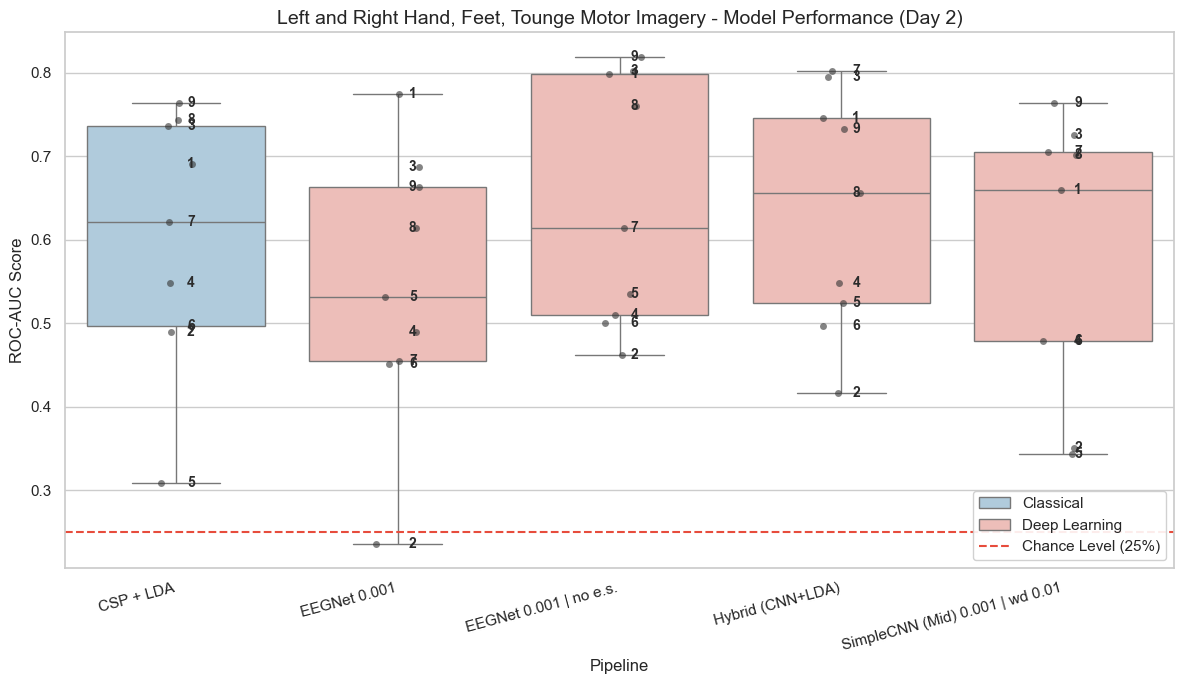

In [ ]:
# Visualization

sns.set_theme(style="whitegrid")
# df_4 = pd.read_csv("../data/4_MI_results_confirmed.csv")
plot_data4 = df_4[df_4["session"] == "1test"].copy()

# Add category column
plot_data4['Model Type'] = plot_data4['pipeline'].apply(
    lambda x: 'Deep Learning' if any(w in x for w in ['CNN', 'EEGNet']) else 'Classical'
)

# Classical First Sort
plot_data4 = plot_data4.sort_values(by=['Model Type', 'pipeline'])

# Plotting
plt.figure(figsize=(12, 7))
my_colors = {"Classical": "#A9CCE3", "Deep Learning": "#F5B7B1"} # Soft Blue & Orange

# The boxes
ax = sns.boxplot(data=plot_data4, x="pipeline", y="score", hue="Model Type",
                 palette=my_colors, dodge=False, showfliers=False)

# Individuals
sns.stripplot(data=plot_data4, x="pipeline", y="score", 
              color="#333333", alpha=0.6, jitter=True)

# -----------------------------------Add Subject IDs to the dots--------------------------------
xtick_labels = [l.get_text() for l in ax.get_xticklabels()]
pipeline_map = {name: i for i, name in enumerate(xtick_labels)}

for i, row in plot_data4.iterrows():
    if row['pipeline'] in pipeline_map:
        x_pos = pipeline_map[row['pipeline']]

        ax.text(x_pos + 0.05, row['score'], str(row['subject']), 
                va='center', size='small', color='#2b2b2b', weight='semibold')
#----------------------------------------------------------------------------------------------------

# Formatting
plt.title("Left and Right Hand, Feet, Tongue Motor Imagery - Model Performance (Day 2)", fontsize=14)
plt.ylabel("ROC-AUC Score", fontsize=12)
plt.xlabel("Pipeline", fontsize=12)

plt.axhline(0.25, color='#e74c3c', linestyle='--', label="Chance Level (25%)")
plt.xticks(rotation=15, ha='right')

handles, labels = ax.get_legend_handles_labels()
plt.legend(handles=handles, labels=labels, loc='lower right', framealpha=0.9)

plt.tight_layout()
# plt.savefig("4_classmotor_clean.png", dpi=300)
plt.show()

> **Note:** The results showcase a close competition between the classical method (CSP-LDA) and the Deep Learning contenders. They are comparable in this test and the differences are mostly in the details.
> 
> **Test:** As a test, I included one model **WITH** Early Stopping, (EEGNet 0.001) and it shows the decrease in performance compared to every other model. Initially, I implemented Early Stopping, but using it comes with giving up a set percentage of your training data due to the validation split. This, on an already scarce dataset, is not a viable option. Utilizing the full training data, the model performs better.

# Saliency Plots


### **What does the model *depend* on for its decisions?**

To interpret the decision-making process of the Deep Learning models, we utilize *Saliency Analysis**. Unlike standard forward-propagation which calculates a prediction from data, this technique employs **Backpropagation to the Input Tensor**.

**The Process:**
1. **Gradient Calculation:** The core mechanism relies on calculating the partial derivative of the output class score (for instance, the probability of a "Left Hand" motor imagery class) relative to the raw input data.
2. **Sensitivity Mapping:** The resulting gradient tensor represents how much a tiny change in a specific electrode's voltage at a specific millisecond would affect the final prediction.
3. **Temporal Aggregation:** Because EEG is a time-series, we take the absolute value of these gradients and average them across the temporal dimension to produce a single **spatial importance weight** for each electrode.
4. **Topographical Visualization:** These values are mapped onto the topographical map system using MNE’s interpolation algorithms, allowing us to visualize which physical regions of the brain the model "prioritized" to reach its conclusion.


--- Computing Saliency Maps for Subject 3 ---
Training temp model...
Computing gradients for class left_hand...
Saved saliency_map_subj3_left_hand_labeled.png

--- Top 5 Most Important Electrodes for left_hand ---
  C3: 0.000468
  CP4: 0.000467
  C4: 0.000342
  CP2: 0.000288
  C6: 0.000267

--- Computing Saliency Maps for Subject 9 ---
Training temp model...
Computing gradients for class right_hand...
Saved saliency_map_subj9_right_hand_labeled.png

--- Top 5 Most Important Electrodes for right_hand ---
  C4: 0.000214
  FC4: 0.000208
  CP4: 0.000204
  P2: 0.000140
  C5: 0.000125

--- Computing Saliency Maps for Subject 8 ---
Training temp model...
Computing gradients for class left_hand...
Saved saliency_map_subj8_left_hand_labeled.png

--- Top 5 Most Important Electrodes for left_hand ---
  CP3: 0.000365
  CP4: 0.000350
  C2: 0.000226
  C5: 0.000211
  POz: 0.000160


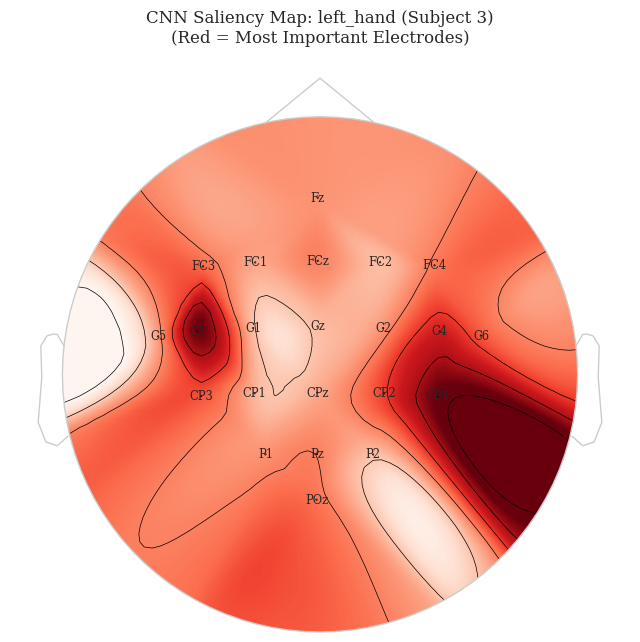

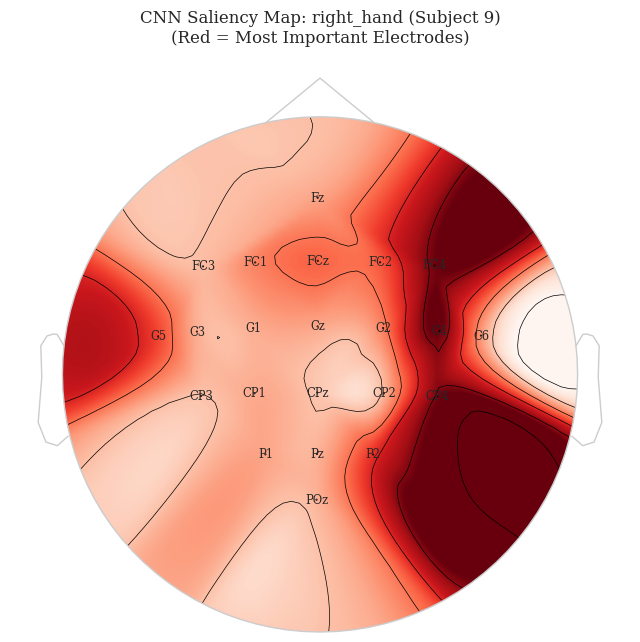

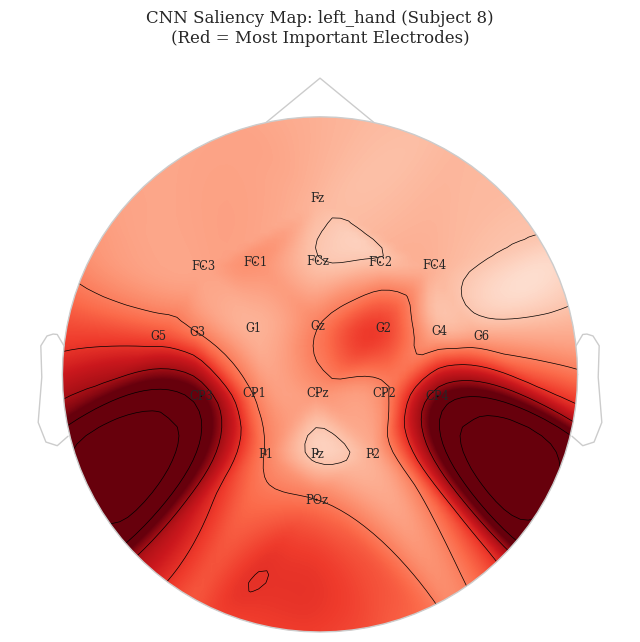

In [ ]:
# Saliency maps: Where is the model *looking* when
# Set logging
moabb.set_log_level("info")

def compute_saliency(subject_id=8, target= 0):
    print(f"\n--- Computing Saliency Maps for Subject {subject_id} ---")
    
    # Load Data
    dataset = BNCI2014_001()
    paradigm = LeftRightImagery(fmin=8, fmax=35)
    X, y, metadata = paradigm.get_data(dataset=dataset, subjects=[subject_id])
    
    # mne raw data acquisition. 
    raw_dict = dataset.get_data(subjects=[subject_id])
    session = list(raw_dict[subject_id].keys())[0]
    run = list(raw_dict[subject_id][session].keys())[0]
    raw = raw_dict[subject_id][session][run]
    raw.pick_types(eeg=True)
    info = raw.info
    
    # 2. Train Model
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    
    n_channels = X.shape[1]
    n_times = X.shape[2]
    n_classes = len(le.classes_)
    # =============== Model ===============
    model = SimpleCNN(n_channels, n_classes, n_times).to(device)
    
    # Create simple dataloader
    X_tensor = torch.FloatTensor(X).unsqueeze(1).to(device)
    y_tensor = torch.LongTensor(y_encoded).to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = torch.nn.CrossEntropyLoss()
    
    print("Training temp model...")
    model.train()
    for _ in range(30):         # much shorter training. Can be done on CPU. 
        optimizer.zero_grad()
        out = model(X_tensor)
        loss = criterion(out, y_tensor)
        loss.backward()
        optimizer.step()
    # ======================================
    # 3. Compute Saliency
    # We want to see what drives the decision for "Left Hand"
    target_class = target # Left Hand: 0 Right Hand: 1 Feet: 2 Tongue: 3
    target_indices = np.where(y_encoded == target_class)[0]
    
    saliencies = []
    
    model.eval()
    print(f"Computing gradients for class {le.classes_[target_class]}...")
    
    for idx in target_indices[:40]: # Average first X trials
        input_tensor = X_tensor[idx].unsqueeze(0).clone()
        input_tensor.requires_grad_()
        
        output = model(input_tensor)
        score = output[0, target_class]
        
        # Backward pass to get gradients w.r.t input
        model.zero_grad()
        score.backward()
        
        grads = input_tensor.grad.data.cpu().numpy()[0, 0]

        # we average and abs the values

        saliency_map = np.mean(np.abs(grads), axis=1) # (Channels,)
        saliencies.append(saliency_map)
        
    avg_saliency = np.mean(saliencies, axis=0)
    
    
    # 4. Plot
    fig, ax = plt.subplots(figsize=(8, 8)) # Increased size for labels
    # Plot with names!
    mne.viz.plot_topomap(avg_saliency, info, axes=ax, cmap='Reds', show=False, names=info.ch_names)
    
    label = le.classes_[target_class]
    ax.set_title(f"CNN Saliency Map: {label} (Subject {subject_id})\n(Red = Most Important Electrodes)")
    
    # Save with labels in filename
    fname = f"saliency_map_subj{subject_id}_{label}_labeled.png"
    plt.savefig(fname)
    print(f"Saved {fname}")
    
    # 5. Print Top Electrodes
    # Pair names with values
    sal_dict = dict(zip(info.ch_names, avg_saliency))
    # Sort by value
    sorted_sensors = sorted(sal_dict.items(), key=lambda item: item[1], reverse=True)
    
    print(f"\n--- Top 5 Most Important Electrodes for {label} ---")
    for name, val in sorted_sensors[:5]:
        print(f"  {name}: {val:.6f}")

# Expected result: Red blobs over the contralateral side of the motor imagery task selected (e.g., left hand -> right hemisphere (C4) importance)
compute_saliency(subject_id=3, target = 0) # Left Hand: 0 Right Hand: 1 Feet: 2 Tongue: 3
compute_saliency(subject_id= 9, target = 1)
compute_saliency(subject_id= 8, target = 0)


### **Caution for Interpretation: Activity vs Importance**

> It is vital to distinguish between **biological neural activity** and **model importance**. A saliency map does not necessarily visualize the physiological Event-Related Desynchronization (ERD); rather, it visualizes the features the model found most discriminative for classification.

*   **Example:** If the training data shows that "Right Hand" imagery always produces a strong ERD on the left hemisphere (C3), the model may learn that the **absence** of a signal on the left side is a strong statistical indicator for a "Left Hand" assignment. 
*   **Result:** In such a scenario, the saliency map may highlight the left hemisphere (C3) as "Highly Important" for a **Left Hand** prediction, even if the actual biological activity is occurring on the right (C4).
*   **Relevance:** This can be a potential interpretation for the pictures above. Many subjects have **right hemisphere** (C4/CP4) as the most important region for the right hand target. 


Overall, a saliency map only shows that the model is sensitive to changes in data at that location, not neuronal firing. I still think this is interesting, but an important limitation. 

---

---

# Hypothesis Testing: Does Biology Predict Model Performance?

**Revisiting the First Code Block**

At the very beginning of this project, I posed that the **Event-Related Desynchronization (ERD)** are the key signals that our machine learning models are learning. The main "hypothesis" is that the massive variance in our results - why Subject 9 achieves almost 100% accuracy while Subject 5 struggles near chance level - is driven by the strength of this biological signal, rather than the architecture of the neural network.

Here, I could test this idea.

### Methodology
The code below calculates an average Event Related Desynchronization (ERD) for each subject by measuring the average desynchronization over the motor cortex that was relevant for their task during the active phase. We will then correlate this value against the final test accuracy.

### Hypothesis
If our Deep Learning models are learning these specific neurophysiological, we should see a **strong** relationship:
* **Stronger ERD (more negative values) $\rightarrow$ Higher Accuracy.**

In [14]:
# Reminder for all potential models:)

df_2.pipeline.unique()

array(['LogVar + LDA', 'LogVar + LogReg', 'SimpleCNN 0.001',
       'Hybrid (CNN+LDA)', 'CSP + LDA', 'EEGNet (Slow) 0.0005'],
      dtype=object)

Calculating ERD Strength for all subjects (this takes a moment)...
Subject 1: ERD Strength = 0.02 (More negative is better)
Subject 2: ERD Strength = 0.20 (More negative is better)
Subject 3: ERD Strength = -0.45 (More negative is better)
Subject 4: ERD Strength = -0.11 (More negative is better)
Subject 5: ERD Strength = -0.11 (More negative is better)
Subject 6: ERD Strength = 0.12 (More negative is better)
Subject 7: ERD Strength = -0.14 (More negative is better)
Subject 8: ERD Strength = -0.04 (More negative is better)
Subject 9: ERD Strength = -0.44 (More negative is better)


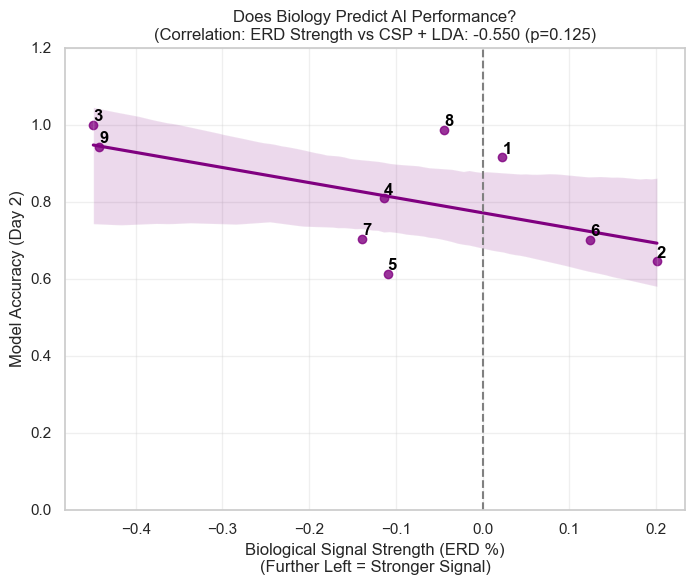

Spearman Correlation: -0.550 (p=0.125)
Interpretation: A strong NEGATIVE correlation means lower (more negative) ERD leads to higher accuracy.


In [ ]:
def calculate_average_erd(dataset, subject, fmin=8, fmax=13):
    """
    Calculates the mean ERD for the task-relevant contralateral electrode
    """
    # Load data for specific subject
    paradigm = LeftRightImagery(fmin=4, fmax=40)
    X, y, _ = paradigm.get_data(dataset=dataset, subjects=[subject])
    
    # We need MNE epochs for TFR
    raw_dict = dataset.get_data(subjects=[subject])
    session = list(raw_dict[subject].keys())[0]
    run = list(raw_dict[subject][session].keys())[0]
    raw = raw_dict[subject][session][run]
    
    events, event_ids = mne.events_from_annotations(raw, verbose=False)
    tmin, tmax = -2, 4
    epochs = mne.Epochs(raw, events, tmin=tmin, tmax=tmax, baseline=None, verbose=False)
    
    # Calculate Power
    freqs = np.arange(fmin, fmax, 1)
    n_cycles = freqs / 2.0

    # A. Right Hand (Expect ERD at C3)
    tfr_right = tfr_multitaper(epochs['2'], freqs=freqs, n_cycles=n_cycles, 
                               use_fft=True, return_itc=False, average=True, verbose=False)

    tfr_right.apply_baseline((-1.5, -0.5), mode='percent', verbose=False)
    
    # B. Left Hand (Expect ERD at C4)
    tfr_left = tfr_multitaper(epochs['1'], freqs=freqs, n_cycles=n_cycles, 
                              use_fft=True, return_itc=False, average=True, verbose=False)

    tfr_left.apply_baseline((-1.5, -0.5), mode='percent', verbose=False)
    
    # Extract Region of Interest Data
    ch_names = tfr_right.info['ch_names']
    idx_c3 = ch_names.index('C3') if 'C3' in ch_names else 0
    idx_c4 = ch_names.index('C4') if 'C4' in ch_names else 1
    
    # Time mask: Active phase (0.5 to 2.5s)
    t_mask = (tfr_right.times >= 0.5) & (tfr_right.times <= 2.5) 
    
    # Get mean power
    val_right = tfr_right.data[idx_c3, :, t_mask].mean()
    val_left = tfr_left.data[idx_c4, :, t_mask].mean()
    
    # Average the two scores (Both "ought to" be negative)
    avg_erd = (val_right + val_left) / 2.0
    
    return avg_erd

# Main Loop
print("Calculating ERD Strength for all subjects (this takes a moment)...")
erd_scores = []
dataset = BNCI2014_001()
subjects = dataset.subject_list # [1, 2, to 9]

for subj in subjects:
    score = calculate_average_erd(dataset, subj)
    erd_scores.append({'subject': subj, 'erd_strength': score})
    print(f"Subject {subj}: ERD Strength = {score:.2f} (More negative is better)")

df_erd = pd.DataFrame(erd_scores)

# Analysis
# Choose a model e.g., "EEGNet (Slow) 0.0005", 'SimpleCNN 0.001', 'CSP + LDA'
target_pipeline = "CSP + LDA"
# df_2 = pd.read_csv('../data/left_right_results_confirmed.csv')
df_acc = df_2[(df_2['pipeline'] == target_pipeline) & (df_2['session'] == '1test')]

# Merge
df_corr = pd.merge(df_acc, df_erd, on='subject')


# === Visualization ===
plt.figure(figsize=(8, 6))
sns.regplot(data=df_corr, x='erd_strength', y='score', color='purple')

# labels
for i, row in df_corr.iterrows():
    plt.text(row['erd_strength'], row['score'] + 0.01, str(row['subject']), 
             fontweight='bold', color='black')
corr, p = spearmanr(df_corr['erd_strength'], df_corr['score'])
plt.title(f"Does ERD Predict Model Performance?\n(Correlation: ERD Strength vs {target_pipeline}: {corr:.3f} (p={p:.3f})")
plt.xlabel("Biological Signal Strength (ERD %)\n(More Negative = Stronger Signal)")
plt.ylabel("Model Accuracy (Day 2)")
plt.axvline(0, color='gray', linestyle='--') # Zero line
plt.grid(True, alpha=0.3)
plt.ylim(0,1.2)
plt.show()

print(f"Spearman Correlation: {corr:.3f} (p={p:.3f})")
print("Interpretation: A strong NEGATIVE correlation means lower (more negative) ERD leads to higher accuracy.")

> ### Results
> I found a strong -0.5 correlation coefficient, but the result was statistically non-significant for EEGNet, SimpleCNN, and CSP + LDA. This shows that there is more to the story and that the underlying logic of these models are not that simple.
>
> **Sample Size:** A sample size of n=9 is probably not enough to pick up on an effect, if there is one here. A bigger pool might've produced the results, as the negative trend is definitely there.
> 
> **Limitation:** Perhaps adding more brain regions (e.g, C6, CP4) to see a more regional effect, rather than a specific electrode would clear up the results, but this is missing so far.

### **Confusion Matrix**

The confusion matrices below visualize the class-specific performance of the models, mapping the true biological labels against the model's predictions. This provides a more granular view of performance than a single accuracy score, highlighting which specific motor imagery tasks are being successfully decoded and which are being confused.

**Key Components:**
*   **Diagonal Elements:** Indicate the percentage of trials correctly classified for each specific task (True Positives).
*   **Off-Diagonal Elements:** Represent misclassifications, showing which motor commands are statistically "similar" or "confusing" to the model.

>**Note**: The code below includes a training loop, but only for a single subject. It is much faster than the full pipeline (~max 6 minutes). You can choose to run it yourself, or simply view the pre-rendered output already visible in the notebook.

2026-02-20 16:33:12,382 WARNING MainThread moabb.paradigms.motor_imagery Choosing from all possible events


Loading data for Subject 3...
Sessions found: ['0train' '1test']
Training on 0train, Testing on 1test
Training CSP + LDA...
Training SimpleCNN...
EEGNetv4 | Epoch 10/150 | Loss: 1.3031 | Acc: 48.26% | GPU Mem: 44.2MB / 1998.0MB
EEGNetv4 | Epoch 20/150 | Loss: 1.1748 | Acc: 61.46% | GPU Mem: 44.2MB / 1998.0MB
EEGNetv4 | Epoch 30/150 | Loss: 1.1220 | Acc: 62.85% | GPU Mem: 44.2MB / 1998.0MB
EEGNetv4 | Epoch 40/150 | Loss: 1.1032 | Acc: 63.89% | GPU Mem: 44.2MB / 1998.0MB
EEGNetv4 | Epoch 50/150 | Loss: 1.0854 | Acc: 61.11% | GPU Mem: 44.2MB / 1998.0MB
EEGNetv4 | Epoch 60/150 | Loss: 1.0564 | Acc: 65.97% | GPU Mem: 44.2MB / 1998.0MB
EEGNetv4 | Epoch 70/150 | Loss: 1.0429 | Acc: 67.36% | GPU Mem: 44.2MB / 1998.0MB
EEGNetv4 | Epoch 80/150 | Loss: 1.0166 | Acc: 69.44% | GPU Mem: 44.2MB / 1998.0MB
EEGNetv4 | Epoch 90/150 | Loss: 0.9857 | Acc: 70.49% | GPU Mem: 44.2MB / 1998.0MB
EEGNetv4 | Epoch 100/150 | Loss: 0.9729 | Acc: 69.79% | GPU Mem: 44.2MB / 1998.0MB
EEGNetv4 | Epoch 110/150 | Loss: 

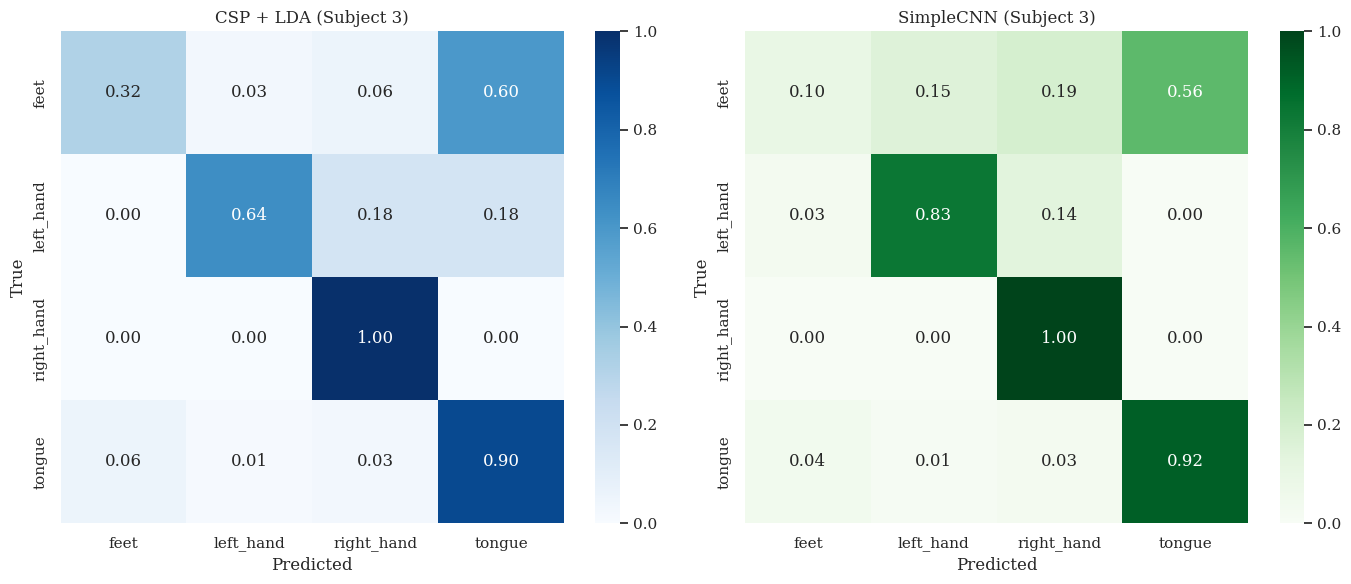

In [ ]:

# Load Data (4 Classes)
subject_id = 3
print(f"Loading data for Subject {subject_id}...")
dataset = BNCI2014_001()
# Note: We use MotorImagery (4 classes), not LeftRightImagery
paradigm = MotorImagery(n_classes=4, fmin=8, fmax=35)
X, y, metadata = paradigm.get_data(dataset=dataset, subjects=[subject_id])

# seession data = [train0, test1]
sessions = metadata['session'].unique()
print(f"Sessions found: {sessions}")
train_session = sessions[0]
test_session = sessions[1]
print(f"Training on {train_session}, Testing on {test_session}")

train_mask = metadata['session'] == train_session
test_mask  = metadata['session'] == test_session

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

# Train Models
# --- Model A: CSP + LDA ---
print("Training CSP + LDA...")
csp = CSP(n_components=8, reg=None, log=True, norm_trace=False)
lda = LDA()
model_csp = make_pipeline(csp, lda)
model_csp.fit(X_train, y_train)
y_pred_csp = model_csp.predict(X_test)

# --- Model B: SimpleCNN ---
print("Training SimpleCNN...")
model_cnn = CNNEstimator(n_epochs=150, batch_size=32, learning_rate=0.001, model_type="EEGNetv4")
model_cnn.fit(X_train, y_train)
y_pred_cnn = model_cnn.predict(X_test)

# Plot Confusion Matrices Side-by-Side
# Labels are ['feet', 'left_hand', 'right_hand', 'tongue']
labels = np.unique(y) 

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot CSP
cm_csp = confusion_matrix(y_test, y_pred_csp, labels=labels)
cm_norm_csp = cm_csp.astype('float') / cm_csp.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm_csp, annot=True, fmt=".2f", cmap="Blues", xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title(f"CSP + LDA (Subject {subject_id})")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

# Plot CNN
cm_cnn = confusion_matrix(y_test, y_pred_cnn, labels=labels)
cm_norm_cnn = cm_cnn.astype('float') / cm_cnn.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm_cnn, annot=True, fmt=".2f", cmap="Greens", xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title(f"SimpleCNN (Subject {subject_id})")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
plt.show()

**Observations:**
The results exhibit significant subject-wise variance. Some common trends are the high scores for right hand and the misattribution of the feet for tongue, which was expected. While some subjects show a clear diagonal, others display more distributed errors. 

### **Subject Performance Profiles and Ranking Stability**

To determine if model performance is a result of biological traits or algorithmic variance, I conducted a **Rank Stability** of subjects across all pipelines. 

**Interpretative Keys:**
*   **Horizontal Lines:** Indicate high biological stability. If a subject (e.g., Subject 3) remains in the Top 3 regardless of the model used, it suggests a robust, "textbook" physiological signal that is easily decoded by any math.
*   **Crossing Lines:** Indicate model-specific sensitivity. If a subject performs poorly on classical models (CSP) but ranks significantly higher on Deep Learning (EEGNet), it suggests the presence of complex, non-linear biological features that simple spatial filters cannot capture.
*   **Consistent Low Rank:** Highlights subjects potentially affected by **BCI Illiteracy**, where the absence of a detectable sensorimotor rhythm makes them "hard" for every architecture tested.

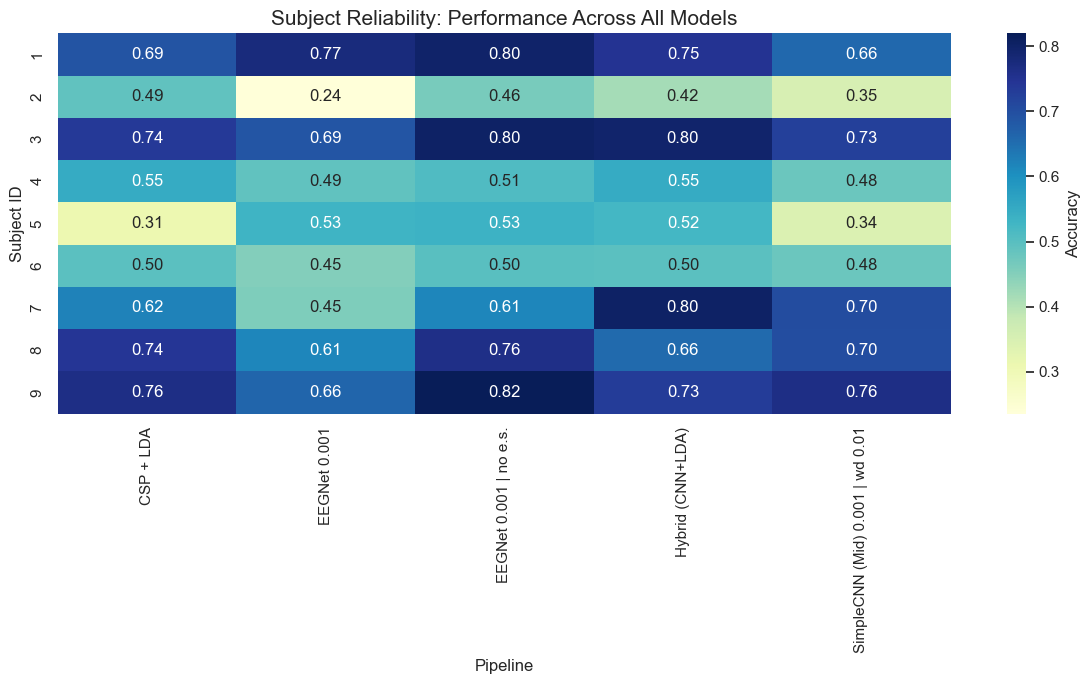

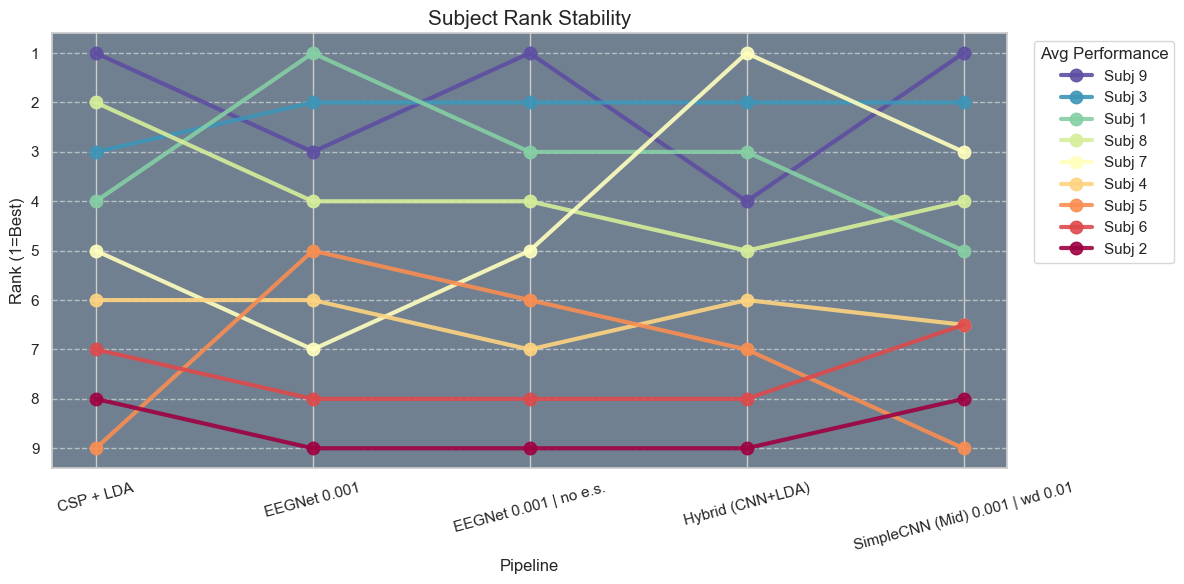

Spearman Correlation (CSP vs EEGNet): 0.912 (p=0.001)


In [30]:
# df_4 = pd.read_csv('../data/4_MI_results_confirmed.csv')
df_4.head()

# =================================================================================================================

# Prep for testing (Day 2)
plot_df = df_4[df_4["session"] == "1test"].copy()

# Create a pivot table: Rows = Subjects, Columns = Pipelines
pivot_df = plot_df.pivot(index="subject", columns="pipeline", values="score")

# Plot 1: Subject-Pipeline Heatmap
plt.figure(figsize=(12, 7))
sns.heatmap(pivot_df, annot=True, cmap="YlGnBu", fmt=".2f", cbar_kws={'label': 'Accuracy'})
plt.title("Subject Reliability: Performance Across All Models", fontsize=15)
plt.ylabel("Subject ID")
plt.xlabel("Pipeline")
plt.tight_layout()
plt.show()

# =================================================================================================================

# 1. Calculate Ranks
rank_df = pivot_df.rank(axis=0, ascending=False)

avg_rank = rank_df.mean(axis=1).sort_values() 
sorted_subjects = avg_rank.index
n_subj = len(sorted_subjects)

plt.figure(figsize=(12, 6))
ax = plt.gca()

ax.set_facecolor('#708090') # to see all colors...
plt.grid(axis='y', linestyle='--', alpha=0.5, color='white') 

for i, subject in enumerate(sorted_subjects):
    color = plt.cm.Spectral(1 - (i / (n_subj - 1)))
    
    plt.plot(pivot_df.columns, rank_df.loc[subject], 
             marker='o', markersize=9, linewidth=3, 
             label=f"Subj {subject}", color=color, alpha=0.9)

plt.gca().invert_yaxis() 
plt.yticks(range(1, 10))
plt.title("Subject Rank Stability", fontsize=15)
plt.ylabel("Rank (1=Best)")
plt.xlabel("Pipeline")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Avg Performance")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()
# =================================================================================================================

# 4. Statistical Correlation: Classical vs Deep Learning
# Does being good at CSP 'predict' being good at EEGNet?
corr, p = spearmanr(pivot_df["CSP + LDA"], pivot_df["SimpleCNN (Mid) 0.001 | wd 0.01"])
print(f"Spearman Correlation (CSP vs EEGNet): {corr:.3f} (p={p:.3f})")


>  
> Interesting results overall; the visualization reveals significant line crossing, indicating that **rank is not stable across models**.  
>  
Notably, **Rank 7** (Subject 6) performs significantly better on the custom `SimpleCNN` model, suggesting the extra parameters allowed that model to learn features the EEGNet was not capable of.

**Rank 9** (Subject 5) was the *worst* performing subject on CSP + LDA; but had much better success with some of the deep learning models. This may mean that some non-linear features were captured by the Neural Networks that CSP couldn't.

**Rank 5** (Subject 7) exhibits the most extreme line crossing; going from 5th on `CSP + LDA`, to the first(!) on the `Hybrid (CNN + LDA)`. This unique pairing of Neural Network, and classical classifier somehow offered a great benefit for this subject.

### **Transfer Learning: Can we "fix" a low-performing subject?**

**The Problem:** Some subjects (like Subject 2 or 5) just don't perform well with standard training. Their signals are either too weak or too noisy for the model to learn from scratch with only ~140 trials.

**The Idea:** Instead of training on just one person, we use **Transfer Learning**. 
1. **Pre-training:** We train the model on all *other* subjects first. This helps the model learn what a "general brain" looks like during motor imagery.
2. **Fine-tuning:** We take that "pre-trained" model and tweak it using the specific target subject’s training data.

**The Goal:** We want to see if this "general brain knowledge" helps the model generalize to the target subject's Day 2 better than the standard baseline.

# Foundation Models + Transfer Learning

--- FOUNDATION MODEL EXPERIMENT (Target Subject 6) ---
Source Subjects (Pre-training): [1, 2, 3, 4, 5, 7, 8, 9]
Target Subject (Fine-tuning): 6

Loading Source Data...
Loading Target Data...
Target Split: Train on 0train, Test on 1test

--- Running Baseline (Train Day 1 -> Test Day 2) ---
EEGNetv4 | Epoch 10/200 | Loss: 0.6900 | Acc: 56.56% | GPU Mem: 31.7MB / 1998.0MB
EEGNetv4 | Epoch 20/200 | Loss: 0.6849 | Acc: 66.39% | GPU Mem: 31.7MB / 1998.0MB
EEGNetv4 | Epoch 30/200 | Loss: 0.6831 | Acc: 63.11% | GPU Mem: 31.7MB / 1998.0MB
EEGNetv4 | Epoch 40/200 | Loss: 0.6821 | Acc: 63.11% | GPU Mem: 31.7MB / 1998.0MB
EEGNetv4 | Epoch 50/200 | Loss: 0.6723 | Acc: 69.67% | GPU Mem: 31.7MB / 1998.0MB
EEGNetv4 | Epoch 60/200 | Loss: 0.6656 | Acc: 66.39% | GPU Mem: 31.7MB / 1998.0MB
EEGNetv4 | Epoch 70/200 | Loss: 0.6566 | Acc: 68.85% | GPU Mem: 31.7MB / 1998.0MB
EEGNetv4 | Epoch 80/200 | Loss: 0.6557 | Acc: 71.31% | GPU Mem: 31.7MB / 1998.0MB
EEGNetv4 | Epoch 90/200 | Loss: 0.6372 | Acc: 71.31% |

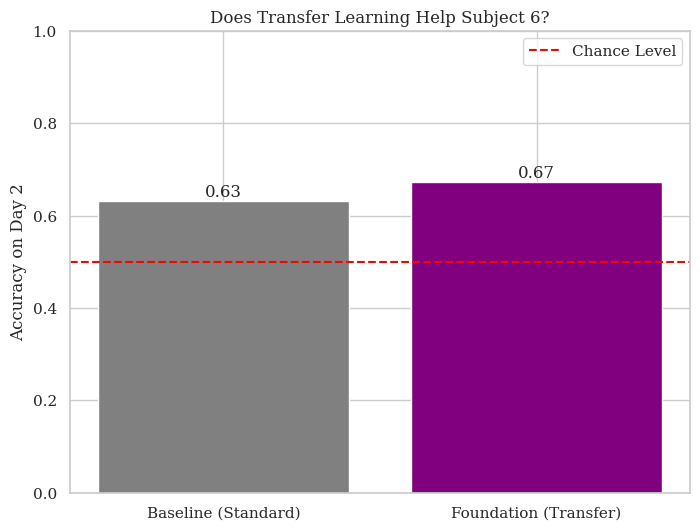

In [ ]:
# Configuration
TARGET_SUBJECT = 2  # The "Bad" subject we want to fix (Try 2? or 7)
BATCH_SIZE  = 32
LR_PRETRAIN = 0.001
LR_FINETUNE = 0.0005 # Lower LR for fine-tuning
EPOCHS_BASE  = 160    # Epochs for "General Brain"
EPOCHS_PRE = 80
EPOCHS_FINE = 50 # Epochs for Fine-Tuning

print(f"--- FOUNDATION MODEL EXPERIMENT (Target Subject {TARGET_SUBJECT}) ---")
# Preparation.


# Load Data
dataset = BNCI2014_001()
paradigm = LeftRightImagery(fmin=8, fmax=35)
all_subjects = dataset.subject_list

# Define Source (Everyone else) vs Target (Our specific user)
source_subjects = [s for s in all_subjects if s != TARGET_SUBJECT]
print(f"Source Subjects (Pre-training): {source_subjects}")
print(f"Target Subject (Fine-tuning): {TARGET_SUBJECT}")

# --- A. Prep. Src Data ---
print("\nLoading Source Data...")
X_src, y_src, _ = paradigm.get_data(dataset=dataset, subjects=source_subjects)

# --- B. Prep. Target Data (Day 1 Train, Day 2 Test) ---
print("Loading Target Data...")
X_tgt, y_tgt, meta_tgt = paradigm.get_data(dataset=dataset, subjects=[TARGET_SUBJECT])

sessions = meta_tgt['session'].unique()
sess_train = sessions[0] # Day 1 (train)
sess_test = sessions[1]  # Day 2 (test)
print(f"Target Split: Train on {sess_train}, Test on {sess_test}")

mask_train = meta_tgt['session'] == sess_train
mask_test = meta_tgt['session'] == sess_test

X_train_tgt, y_train_tgt = X_tgt[mask_train], y_tgt[mask_train]
X_test_tgt, y_test_tgt   = X_tgt[mask_test], y_tgt[mask_test]



# ==========================================
# PIPELINE 1: BASELINE
# ==========================================
print("\n--- Running Baseline (Train Day 1 -> Test Day 2) ---")
est_base = CNNEstimator(n_epochs=EPOCHS_PRE, batch_size=BATCH_SIZE, learning_rate=LR_PRETRAIN, model_type="EEGNetv4", early_stopping=True, patience=40, val_split = 0.15)
est_base.fit(X_train_tgt, y_train_tgt)
final_acc_base = est_base.score(X_test_tgt, y_test_tgt)
print(f"Baseline Final Test Accuracy: {final_acc_base*100:.2f}%")

# ==========================================
# PIPELINE 2: FOUNDATION MODEL (Transfer)
# ==========================================
print("\n--- Running Foundation Model (Pre-train Others -> Fine-tune Day 1 -> Test Day 2) ---")

# Pre-training
print("  > Step 1: Pre-training on Source Subjects...")
est_source = CNNEstimator(n_epochs=EPOCHS_BASE, batch_size=BATCH_SIZE, learning_rate=LR_PRETRAIN, model_type="EEGNetv4", early_stopping=False, patience=40, val_split = 0.15)
est_source.fit(X_src, y_src)

# Extract the Weights
source_weights = est_source.model.state_dict()
    
# Fine-tuning
print("  > Step 2: Fine-tuning on Target Subject (Day 1)...")
est_transfer = CNNEstimator(n_epochs=EPOCHS_FINE, batch_size=BATCH_SIZE, learning_rate=LR_FINETUNE, pretrained_weights=source_weights, model_type="EEGNetv4", early_stopping=False, patience=40)
est_transfer.fit(X_train_tgt, y_train_tgt)

final_acc_transfer = est_transfer.score(X_test_tgt, y_test_tgt)
print(f"Foundation Model Final Test Accuracy: {final_acc_transfer*100:.2f}%")

# ==========================================
# VISUALIZATION
# ==========================================
plt.figure(figsize=(8, 6))
bars = plt.bar(['Baseline (Standard)', 'Foundation (Transfer)'], 
        [final_acc_base, final_acc_transfer], 
        color=['gray', 'purple'])

plt.axhline(0.5, color='r', linestyle='--', label='Chance Level')
plt.ylim(0, 1.0)
plt.ylabel('Accuracy on Day 2')
plt.title(f'Does Transfer Learning Help Subject {TARGET_SUBJECT}?')
plt.bar_label(bars, fmt='%.2f')
plt.legend()

plt.savefig(f"foundation_transfer_subj{TARGET_SUBJECT}.png")
print(f"\nPlot saved to foundation_transfer_subj{TARGET_SUBJECT}.png")

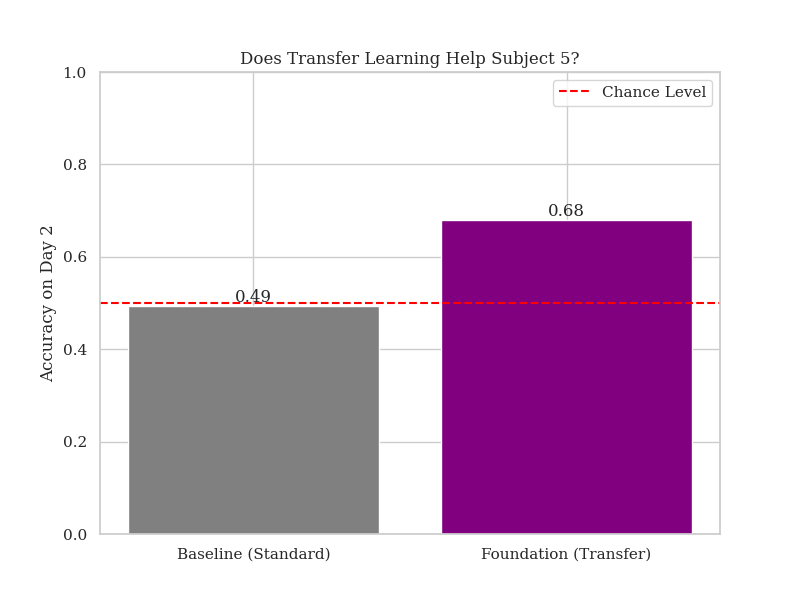

In [4]:
# A somewhat successful example

Image(filename = "Transfer_learning/foundation_subj5_o.png")

### Discussion: Transfer Learning in BCI

While Transfer Learning (TL) is a very successful and lucrative endeavor in domains like Computer Vision, its application to EEG data - particularly on the BCI Competition IV-2a dataset - was very difficult to implement. In my testing, pre-training a "Foundation Model", and fine-tuning on a low-performing target subject (e.g., Subject 5) yielded mixed or limited improvements. 

From my research, BCI literature explains this problem through two main phenomena:

**1. Covariance Shift and Spatial Misalignment**
Every human brain has a unique cortical folding pattern, and slight variations in the EEG cap placement alter the spatial distribution of the signal. A spatial filter (like `conv_spat`) that perfectly isolates the Mu-rhythm for Subject 3 might capture nothing but noise for Subject 5. 
*   **How others solve it:** Studies have shown that simply transferring neural network weights is often insufficient. For instance, He & Wu (2020) implemented **Euclidean Alignment (EA)**, a highly efficient pre-processing step that aligns the data distributions of the source and target subjects before feeding them into the CNN. Alternatively, Zanini et al. (2018) utilized a **Riemannian Alignment (RA)** method. While I initially considered incorporating a similar alignment technique, I ultimately decided against it, as its mathematical complexity fell outside the practical scope of this project.

**2. The Risk of Negative Transfer (BCI Illiteracy)**
Transfer learning assumes the target subject actually produces the underlying physiological features (like ERD) that the model was pre-trained to detect. If a subject is a "low-responder" or exhibits BCI illiteracy, these signals are essentially missing. 
*   **The Consequence:** When a model pre-trained on a high-accuracy subject is applied to a subject with no distinct ERD, it can experience *negative transfer* (Jayaram et al., 2016). Instead of providing a useful head-start, the pre-trained weights force the network to search for features that don't exist in that specific user's brain. This pushes the model to fit to random noise, which can actually result in worse performance than just training from scratch. This was observed in a number of my own transfer learning attempts. 

**Conclusion:**
Overall, my attempt for transfer learning was very subject-dependent (as everything before...). For some subjects it produced positive results, but some gained nothing. Alignment methods are needed for more robust results.

---

---

# **Results & Discussion**

### **1. Binary Classification (Left vs. Right Hand)**
In the Cross-Session evaluation, Deep Learning demonstrated a clear advantage.
*   **Top Performers:** The **EEGNet (Mid)** and **SimpleCNN 0.001** models achieved the highest accuracy (90+%), consistently beating the classical CSP baseline (82%).
*   **Takeaway:** Deep Learning models are more effective in motor imagery tasks, as they can learn complex patterns and relationships in the data that classical methods may miss. On a personal note, my 'mission' was to get the best possible results with my custom CNN implementation, hoping to beat the baseline, so I will take this as a success.

### **2. Multi-Class Classification (4-Class)**
Running the 4-class task (Left, Right, Feet, Tongue) significantly increased difficulty, dropping the chance level to **25%**.
*   **Top performers:** The deep learning models tied for the best performance, with medians around **65%**, except for **EEGNet 0.001**. This model was left there as a test, as **Early Stopping** was left *on* for this Neural Network only, at a 15% validation split. This lead to markedly lower results overall, showcasing that all of the available data is necessary in such a scarce dataset.
*   **CSP:** The classical **CSP + LDA** pipeline held its own here, actually outperforming the standard EEGNet.
*   **Generalization:** Despite the difficulty, the best models consistently achieved ~65% median accuracy, with 'good' participants reaching 90% (Subject 9), which is far above the chance level of 25%, proving the models are learning valid patterns. I note this section as a success for me as well.

### **3. Subject Reliability & "BCI Illiteracy"**
A major finding is the massive variance between subjects.
*   **High-Responders (e.g., Subject 3, 9):** Consistently achieved high accuracy across all tasks. In my testing, their  **Topomaps** showed much clearer, textbook contralateral ERD, pointing to their potential role in the model learning - however, this relationship wasn't confirmed in this project.
*   **Low-Responders (e.g., Subject 2):** This subject performed near chance level across almost every pipeline. Our **Time-Frequency Plots** confirmed that this subject exhibited almost no detectable ERD in the Mu-band, which may have played a role in the results.

### **4. Model 'Inspection'**
What the model based its decisions on was revealed by the **Saliency Maps**. The models placed the highest importance on electrodes relevant to the task (C4-C3, or nearby parietal electrodes for Left-Right) rather than frontal electrodes. This confirms that despite the noise and lack of ICA preprocessing, the CNNs successfully learned to isolate the relevant motor cortex activity, and not learn noise from eye movements.

---

# **Final Thoughts**

If this project proved one thing, it’s that EEG data is notoriously messy. In machine learning, there is a concept called **Bayes Error** —the absolute lowest possible error rate any model can achieve given the inherent noise in the data. Because EEG has such a low signal-to-noise ratio, the Bayes Error in BCI tasks is naturally quite high. 

Our goal isn't to achieve 100% accuracy, but to push our models as close to that theoretical limit as possible. I really like how this analogy between Michelangelo and machine learning frames the problem:

> *"Michelangelo's view [was] that he did not create sculptures from blocks of stone, but rather that his task as an artist was to reveal forms already present in the stone by chiseling away the superfluous marble. Similarly, in machine learning, our task is to remove noise in the data to reveal information about the class labels."*
>
> **(Vourvopoulos et al., 2026)**

In this project, we relied on bandpass filters, spatial convolutions, and data standardization to act as our tools for 'chipping' away this irrelevant noise and exposing the true physiological patterns.

However, there is a hard limit to what the math can fix. While we can successfully filter out general noise, "human" variables actively increase that irreducible error. A subject simply being less focused on Day 2, or the EEG cap being shifted by just a couple of centimeters between sessions, alters the underlying data distribution entirely and immediately hurts cross-session generalization. 

*   **Subject Variance:** This can also be explained by subject variance; some people are just "High-Responders" (Subject 3 and 8), and some are "Low-Responders" (Subject 2). This is likely biologic (BCI illiteracy), not a bug in the code.

### **PyTorch vs. Keras: My Takeaway**
As I was working on it and looking at a *lot* of publications, documentations, github implementations, etc., and learning more about keras and scikit-learn, I have mixed feelings about using **PyTorch** for this. 
*   **The Complication:** In Keras, normalization, or regularization techniques like `MaxNorm` constraints are just a single function. In PyTorch, I had to write the loop myself. On one hand, this made the code much longer and "convoluted". However, because I chose the manual route I actually had to learn how Pytorch and "outsider" libraries work with Scikit-learn and what scikit-learn requires for its pipelines to work. I now understand the library internals—how the pipelines handle fit/transform and how the data actually is handled by the tensors - much better than if I had just used a high-level library.
*   **Efficiency:** Perhaps, if I were doing this for the most "efficient" and "pretty" code, or needed quick model visualizations, **Keras** might be the better/faster choice. But for learning the intricacies of Biological Data Science, the PyTorch struggle was worth it.

### **Additional (still important) takeaways**
1.  **Standardization:** Scaling the data matters more than adding extra layers to your neural network. Neural networks can be very sensitive to nonstandardized data and too high/low numbers.
2.  **Biology > Math:** Understanding and dealing with the biological data - such as by visualization with topomaps - is essential to see, interpret and debug your results. If there is no effect to observe, there is no "magic" model that will work either. 
3.  **Hyperparameters:** Deep learning hyperparameter tuning is an extremely difficult and often a hopeless endeavor - especially on a slow laptop where training takes 60+ minutes. 
4.  **Early Stopping:** On this note, early stopping was a helpful "idea", as it helps reducing this hyperparameter tuning problem. Instead, we can simply set epochs extremely high, and stop training automatically when the validation loss stops decreasing. However, with a dataset this small, it's a big tradeoff to use early stopping. For one, we are limiting the already small dataset by our validation set percentage. Furthermore, our validation set is not a representative sample of the test set either, and can be significantly impeded by noise.
As a concrete example, initially Subject 5 performed near chance-level when using a 15% validation split for Early Stopping. However, when Early Stopping was disabled—allowing the network to train on 100% of the Day 1 trials—Subject 5's accuracy jumped to roughly 85% on the Left-Right Classification. This shows that for subjects with weak physiological signals, maximizing the volume of training data is more critical than preventing theoretical over-fitting.


# References

Chen, R., Yaseen, Z., Cohen, L. G., & Hallett, M. (2005). Beta rebound after different types of motor imagery in man. Neuroscience Letters, 378(3), 156–159. https://doi.org/10.1002/ana.410440306

He, H., & Wu, D. (2020). Transfer Learning for Brain-Computer Interfaces: A Euclidean Space Data Alignment Approach. IEEE Transactions on Biomedical Engineering, 67(2), 399–410. https://doi.org/10.1109/TBME.2019.2913914

Jayaram, V., Alamgir, M., Altun, Y., Scholkopf, B., & Grosse-Wentrup, M. (2016). Transfer Learning in Brain-Computer Interfaces. IEEE Computational Intelligence Magazine, 11(1), 20–31. https://doi.org/10.1109/MCI.2015.2501545

Lawhern, V. J., Solon, A. J., Waytowich, N. R., Gordon, S. M., Hung, C. P., & Lance, B. J. (2018).  EEGNet: a compact convolutional neural network for EEG-based brain–computer interfaces. Journal of Neural Engineering, 15(5), 056013. https://doi.org/10.1088/1741-2552/aace8c

Pfurtscheller, G., Neuper, C., Brunner, C., & Lopes Da Silva, F. (2005). Beta rebound after different types of motor imagery in man. Neuroscience Letters, 378(3), 156–159. https://doi.org/10.1016/j.neulet.2004.12.034

Pfurtscheller, G., & Lopes Da Silva, F. H. (1999). Event-related EEG/MEG synchronization and desynchronization: basic principles. Clinical Neurophysiology, 110(11), 1842–1857. https://doi.org/10.1016/S1388-2457(99)00141-8

Tangermann, M., Müller, K.-R., Aertsen, A., Birbaumer, N., Braun, C., Brunner, C., Leeb, R., Mehring, C., Miller, K. J., Müller-Putz, G. R., Nolte, G., Pfurtscheller, G., Preissl, H., Schalk, G., Schlögl, A., Vidaurre, C., Waldert, S., & Blankertz, B. (2012). Review of the BCI Competition IV. Frontiers in Neuroscience, 6. https://doi.org/10.3389/fnins.2012.00055

Vidaurre, C., & Blankertz, B. (2009). Towards a Cure for BCI Illiteracy. Brain Topography 2009 23:2, 23(2), 194–198. https://doi.org/10.1007/s10548-009-0121-6

Vourvopoulos, A., Kostoglou, K., Corsi, M.-C., Chevallier, S., Eder, M., Mattersberger, M., Žák, M. R., Grosse-Wentrup, M., Lotte, F., Daly, I., & Papadopoulo, T. (2026). Methods for brain–computer interfacing. Brain–Computer Interfaces, 4-1-4–78. https://doi.org/10.1088/978-0-7503-5914-6ch4

Wolpaw, J. R., Birbaumer, N., McFarland, D. J., Pfurtscheller, G., & Vaughan, T. M. (2002). Brain–computer interfaces for communication and control. Clinical Neurophysiology, 113(6), 767–791. https://doi.org/10.1016/S1388-2457(02)00057-3

Zanini, P., Congedo, M., Jutten, C., Said, S., & Berthoumieu, Y. (2018). Transfer Learning: A Riemannian Geometry Framework With Applications to Brain-Computer Interfaces. IEEE Transactions on Bio-Medical Engineering, 65(5), 1107–1116. https://doi.org/10.1109/TBME.2017.2742541